# Week 6 Phase 3 — model-and-target robustness

**Burak Öztürk · TUM Mathematics MSc thesis**

This notebook is an executed, human-readable report of the exact
simulation-level experiment. The reusable source performs the long
fits with checkpoints; this notebook loads the validated outputs and
explains what they do and do not establish.

```text
Phase 3
├── simple-model test
├── kernel/nugget test
└── target-definition test
```

Strict scope: no ARD, feature importance, causal feature-effect
claim, kinetic energy, total height, active learning, level-set
estimation, or GP classification.

## §0 — provenance, populations, and common protocol

All predictions use exactly `X = [P, VX, LS, ST]`. Targets are
converted only by \(y_{\mu m}=10^6 y_m\). Width and length use all
241 simulations; depth uses the exact 230 stable simulations fixed
in Phase 2.5.

Branch: codex/week6-phase3-model-target-robustness
HEAD: b112f6b22898976f77410190614cb4fb218d38f9
Phase 1 revision: 0e859b748fdbc8454f66e58e101e333ac0479d42
Ledger SHA-256: 10DEF11AB64D62444AC14FED506266BEB748EEB5BF892ACDC12E7F0F6DDCF4FF


,target,population_size,excluded_count,target_min_um,target_median_um,target_max_um
0,width,241,0,86.30895,159.00522,256.767050
1,length,241,0,116.16170,341.37590,543.726450
2,depth,230,11,18.77861,54.72232,94.365085


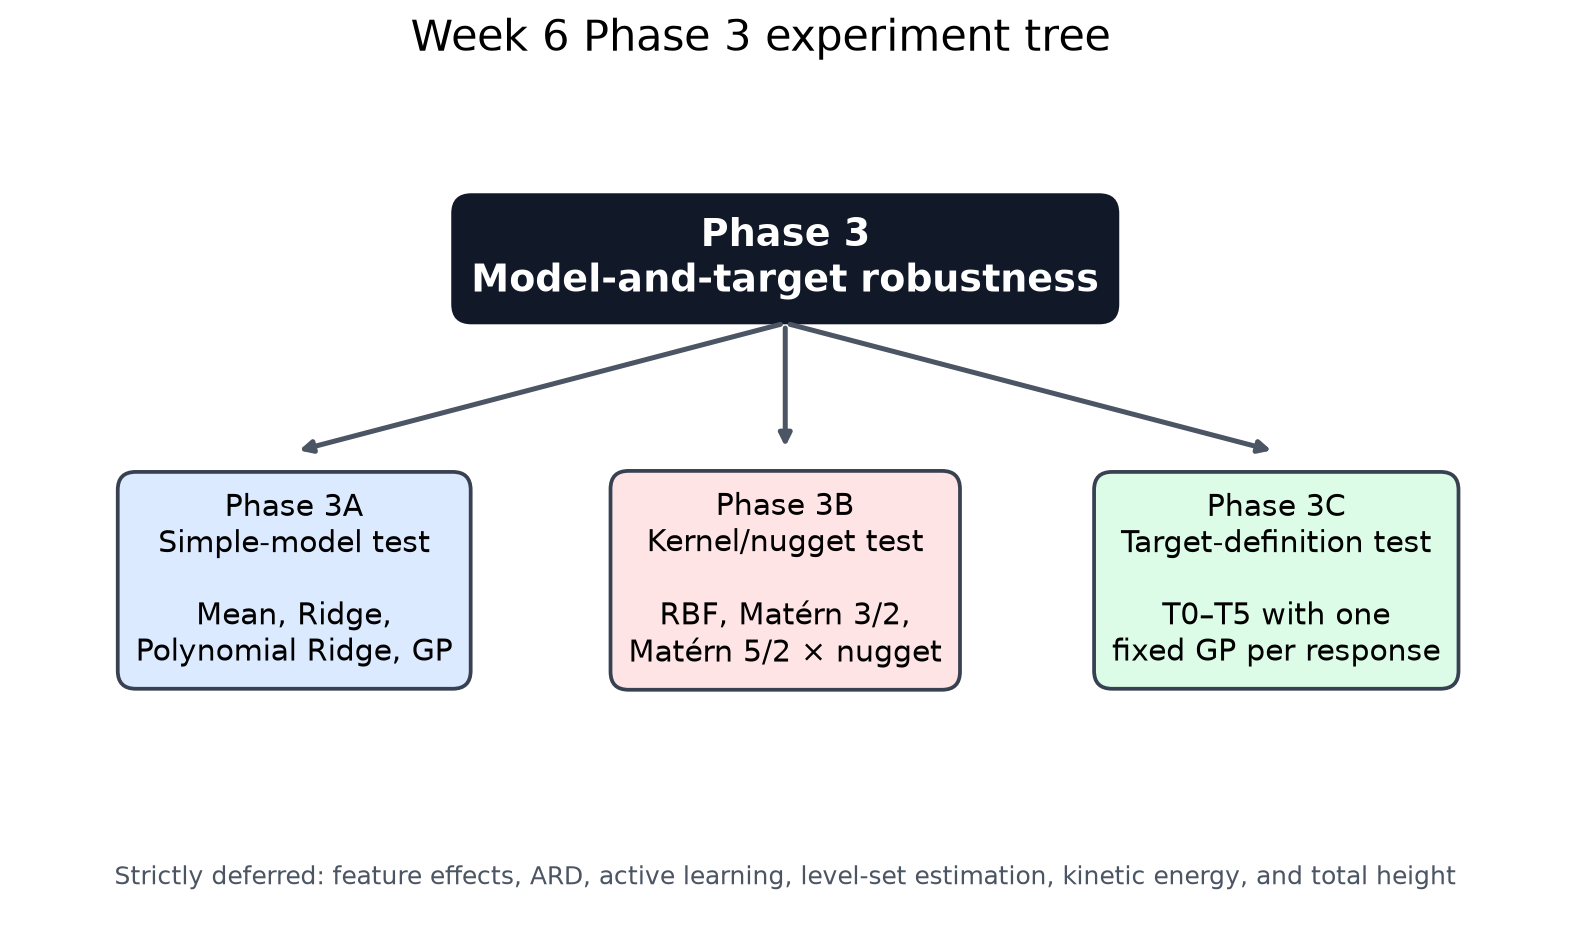

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
OUT = ROOT / "outputs" / "week6_03_model_target_robustness"
FIG = OUT / "figures"
config = json.loads((OUT / "phase3_configuration.json").read_text(encoding="utf-8"))
populations = pd.read_csv(OUT / "phase3_input_population_summary.csv")
runtime = json.loads((OUT / "phase3_runtime_provenance.json").read_text(encoding="utf-8"))

print("Branch:", runtime["repository"]["branch"])
print("HEAD:", runtime["repository"]["head"])
print("Phase 1 revision:", config["phase1_revision"])
print("Ledger SHA-256:", config["phase1_ledger_sha256"])
display(populations[["target", "population_size", "excluded_count",
                     "target_min_um", "target_median_um", "target_max_um"]])
display(Image(filename=str(FIG / "01_phase3_experiment_tree.png")))

**What was done.** The immutable revision, ledger hash, worktree, four
features, and three target-specific populations were loaded before any
result.

**Why.** A robustness comparison is only fair when every model sees the
same simulations, outer fold order, units, and inputs.

**What the result means.** The table is the population contract for all
later cells; depth alone excludes the eleven predeclared unstable IDs.

**What cannot be concluded.** Provenance checks establish
reproducibility, not physical correctness by themselves.

## Part 1 — Phase 3A: simple baselines

**Ridge** is linear regression with **regularization**, a penalty that
discourages very large coefficients. If two coefficients fit almost
equally well, Ridge prefers the more restrained solution.

**Polynomial features** add transformed inputs before regression. At
degree 2, four inputs become their original terms, four squares, and
six pairwise interactions. For a toy input \((x_1,x_2)\), the added
terms are \(x_1^2,x_1x_2,x_2^2\). No degree above 2 is searched.

**Nested cross-validation** separates tuning from evaluation.

- The **outer LOO** (leave-one-out) fold holds out exactly one
  simulation for the scientific prediction.
- The **inner CV** splits only the remaining outer-training simulations
  into five folds to select Ridge's alpha.

Thus the held-out target never chooses preprocessing or alpha.

A **paired bootstrap** resamples simulation IDs jointly for two models.
A 95% **confidence interval** is the middle 95% of 10,000 paired
resampled differences. Here “simple model − GP” below zero favors the
simple model; an interval crossing zero is statistically non-robust.

,target,model,mae_um,median_absolute_error_um,rmse_um,r2,nrmse,aggregate_fold_runtime_seconds
0,depth,linear_ridge,3.352297,2.710386,4.632403,0.910307,0.061286,214.752406
1,depth,matern32_learned_nugget,1.802271,1.339809,2.728943,0.968873,0.036104,216.583352
2,depth,polynomial_ridge_degree2,2.585895,1.837619,3.888507,0.936800,0.051444,344.315785
3,depth,training_mean,12.684469,10.961866,15.535254,-0.008753,0.205530,0.000000
4,length,linear_ridge,25.887851,21.822262,35.830340,0.843130,0.083801,225.769504
5,length,matern32_learned_nugget,10.622780,5.348060,19.389062,0.954064,0.045348,257.359802
6,length,polynomial_ridge_degree2,18.100570,14.887902,25.663039,0.919526,0.060021,351.288015
7,length,training_mean,77.975710,78.804871,90.842009,-0.008351,0.212464,0.000000
8,width,linear_ridge,6.904674,4.786377,9.551436,0.934908,0.056034,223.090758
9,width,matern32_learned_nugget,3.274486,1.907692,6.696355,0.968006,0.039284,469.731782


,target,candidate_model,observed_mae_difference_um,mae_difference_ci95_lower_um,mae_difference_ci95_upper_um,observed_rmse_difference_um,rmse_difference_ci95_lower_um,rmse_difference_ci95_upper_um,simple_model_competitive
0,depth,linear_ridge,1.550026,1.208701,1.894673,1.903461,1.430979,2.340107,False
1,depth,polynomial_ridge_degree2,0.783624,0.521619,1.046284,1.159565,0.709568,1.570066,False
2,length,linear_ridge,15.265071,12.677949,17.925460,16.441278,11.482714,21.479686,False
3,length,polynomial_ridge_degree2,7.477790,6.114172,8.861753,6.273978,3.969389,8.596295,False
4,width,linear_ridge,3.630189,3.054716,4.213998,2.855081,1.285637,4.568484,False
5,width,polynomial_ridge_degree2,0.113178,-0.070639,0.300382,0.028967,-0.143943,0.192350,True


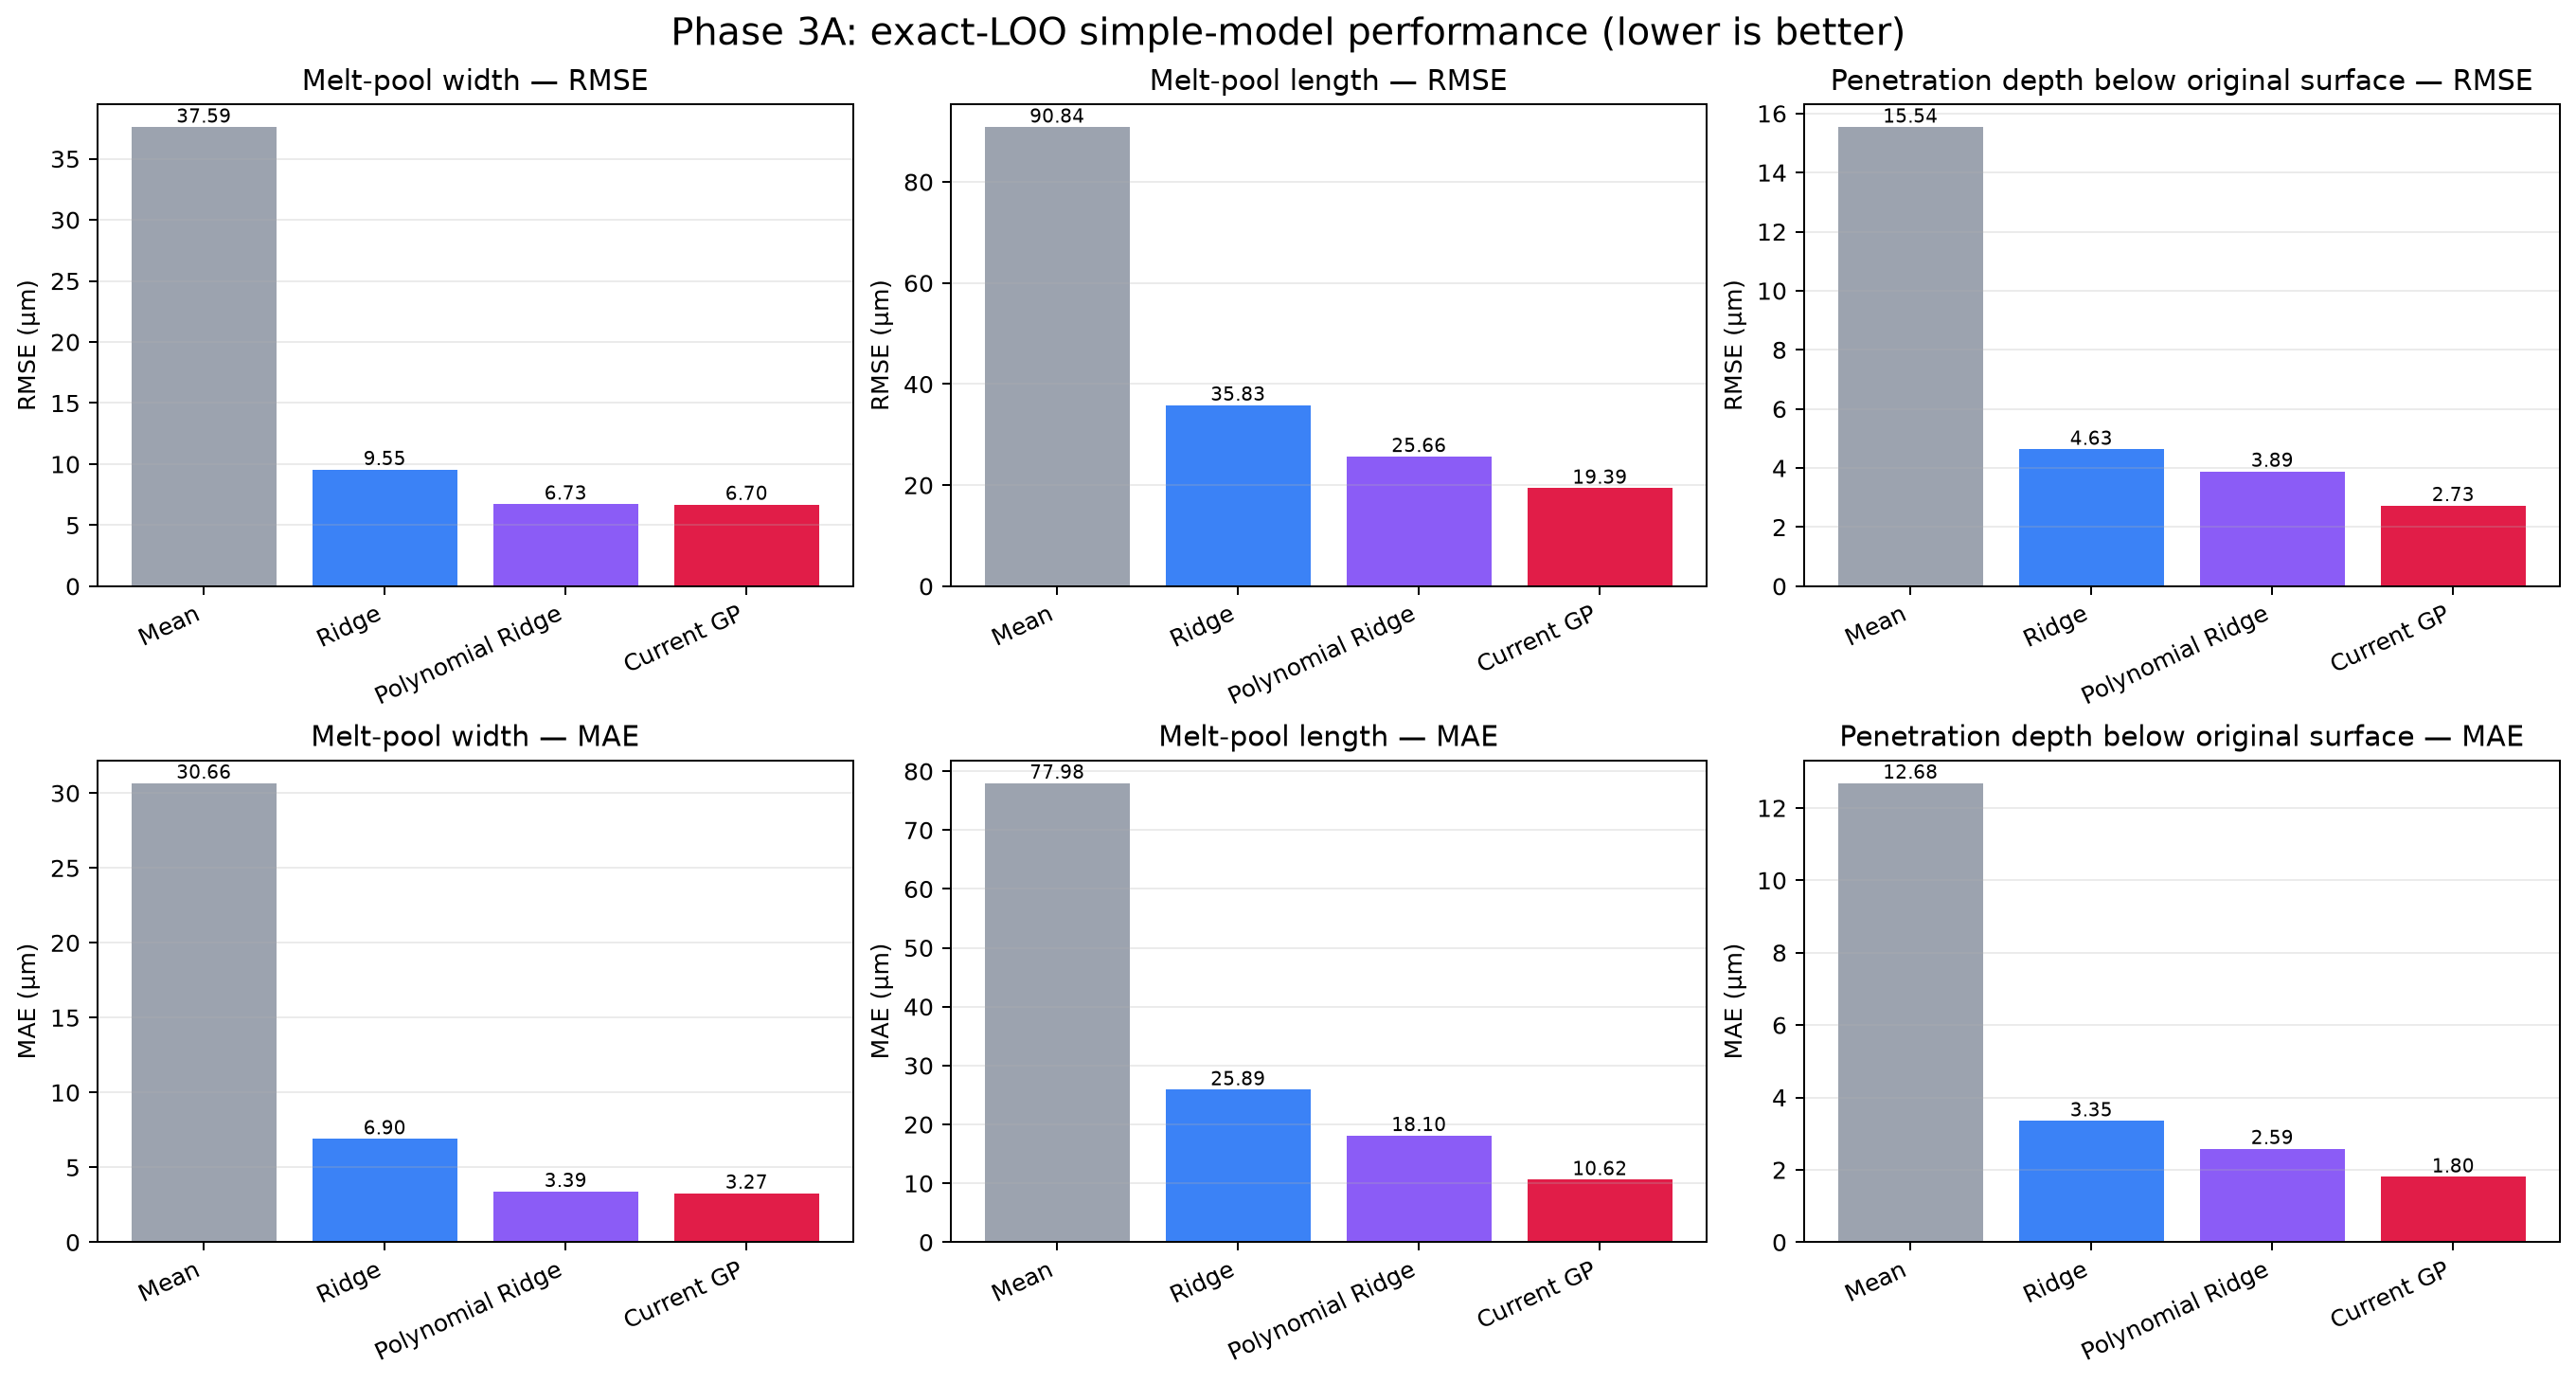

In [2]:
simple_metrics = pd.read_csv(OUT / "simple_baseline_metrics.csv")
simple_pairs = pd.read_csv(OUT / "simple_baseline_paired_bootstrap_summary.csv")
display(simple_metrics[["target", "model", "mae_um",
                        "median_absolute_error_um", "rmse_um",
                        "r2", "nrmse",
                        "aggregate_fold_runtime_seconds"]])
display(simple_pairs[["target", "candidate_model",
                      "observed_mae_difference_um",
                      "mae_difference_ci95_lower_um",
                      "mae_difference_ci95_upper_um",
                      "observed_rmse_difference_um",
                      "rmse_difference_ci95_lower_um",
                      "rmse_difference_ci95_upper_um",
                      "simple_model_competitive"]])
display(Image(filename=str(FIG / "02_simple_model_performance_comparison.png")))

### What the Phase 3A result means

- **Width:** `linear_ridge` minus GP RMSE +2.855 µm (95% CI +1.286 to +4.568); `polynomial_ridge_degree2` minus GP RMSE +0.029 µm (95% CI -0.144 to +0.192). Final point-model decision: `polynomial_ridge_degree2`.
- **Length:** `linear_ridge` minus GP RMSE +16.441 µm (95% CI +11.483 to +21.480); `polynomial_ridge_degree2` minus GP RMSE +6.274 µm (95% CI +3.969 to +8.596). Final point-model decision: `matern52_learned_nugget`.
- **Depth:** `linear_ridge` minus GP RMSE +1.903 µm (95% CI +1.431 to +2.340); `polynomial_ridge_degree2` minus GP RMSE +1.160 µm (95% CI +0.710 to +1.570). Final point-model decision: `matern32_learned_nugget`.

**Why it matters.** A GP is only necessary for point prediction if its paired advantage is statistically robust and practically meaningful. If a Ridge model is competitive, parsimony favors the simpler point model.

**What cannot be concluded.** Ridge has no directly comparable GP predictive distribution in this experiment. Similar point error does not mean that Ridge inherits GP uncertainty, NLPD, or coverage.

In [3]:
ridge_hyper = pd.read_csv(OUT / "simple_baseline_selected_hyperparameters.csv")
alpha_summary = (ridge_hyper
                 .groupby(["target", "model"])["selected_ridge_alpha"]
                 .agg(["min", "median", "max", "nunique"])
                 .reset_index())
display(alpha_summary)
print("Every row used five inner folds:",
      set(ridge_hyper["inner_cv_folds"].astype(int)))
print("Alpha grid:", config["phase3a"]["ridge_alpha_grid"])

,target,model,min,median,max,nunique
0,depth,linear_ridge,0.000001,0.000001,1.0,5
1,depth,polynomial_ridge_degree2,0.000001,1.000000,1.0,4
2,length,linear_ridge,0.000001,1.000000,1.0,5
3,length,polynomial_ridge_degree2,0.000001,1.000000,10.0,4
4,width,linear_ridge,0.000001,0.000001,1.0,4
5,width,polynomial_ridge_degree2,0.000001,0.000001,1.0,4


Every row used five inner folds: {5}
Alpha grid: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0]


**What was done.** The selected alpha was retained for every outer
fold, and its distribution is shown rather than hiding tuning
variability.

**Why.** Fold-specific alpha choices verify that tuning occurred inside
each outer training set.

**What the result means.** A broad alpha distribution indicates that
the preferred amount of shrinkage changes when one simulation is
removed; a narrow distribution indicates stable tuning.

**What cannot be concluded.** Alpha magnitude is not a feature-effect
measure and does not identify which physical input is important.

## Part 2 — Phase 3B: kernel and nugget robustness

A GP kernel specifies how outputs co-vary with input distance.

- **RBF** is very smooth.
- **Matérn 3/2** allows rougher functions.
- **Matérn 5/2** is intermediate between RBF and Matérn 3/2.
- The **lengthscale** controls how quickly correlation falls with
  standardized input distance: a smaller value permits faster change.
- `ConstantKernel × base kernel` controls the overall vertical
  covariance or **signal variance**. It does *not* add a constant
  prediction to the mean. The base kernel controls how correlation
  decays; the ConstantKernel controls how large function variation may
  be.
- **WhiteKernel** learns a diagonal effective **nugget**. It can absorb
  target instability, omitted structure, numerical/model discrepancy,
  or kernel mismatch; it is not automatically simulator noise.
- Tiny numerical **jitter** (`alpha`) stabilizes matrix calculations
  and is kept separate from the learned nugget.

**NLPD** (negative log predictive density) scores both prediction error
and predicted uncertainty; lower is better. **Calibration** asks
whether, for example, about 95% of observations fall inside nominal
95% intervals. Perfect point error does not guarantee good calibration.

,target,gp_configuration,mae_um,rmse_um,mean_nlpd,latent_95_coverage,total_95_coverage,optimizer_warning_folds,any_bound_hit_folds
0,depth,matern32_learned_nugget,1.802271,2.728943,2.440425,0.878261,0.952174,1,0
1,depth,matern32_no_nugget,2.089181,3.036855,2.712522,0.917391,NaN,3,0
2,depth,matern52_learned_nugget,1.788254,2.716966,2.439925,0.821739,0.947826,0,0
3,depth,matern52_no_nugget,2.413463,3.497484,2.952442,0.921739,NaN,0,0
4,depth,rbf_learned_nugget,1.825490,2.769847,2.462972,0.734783,0.956522,0,0
5,depth,rbf_no_nugget,3.402535,4.858216,3.256675,0.921739,NaN,0,0
6,length,matern32_learned_nugget,10.622780,19.389062,4.472069,0.883817,0.954357,1,0
7,length,matern32_no_nugget,15.073931,25.738976,5.377487,0.933610,NaN,0,0
8,length,matern52_learned_nugget,10.361960,18.940151,4.437770,0.871369,0.954357,1,0
9,length,matern52_no_nugget,18.897076,30.752551,5.924299,0.941909,NaN,0,0


,target,selected_provisional_gp_configuration,another_kernel_replaces_current,rationale
0,width,matern32_learned_nugget,False,No alternative jointly showed robust MAE and R...
1,length,matern52_learned_nugget,True,matern52_learned_nugget satisfies the predecla...
2,depth,matern32_learned_nugget,False,No alternative jointly showed robust MAE and R...


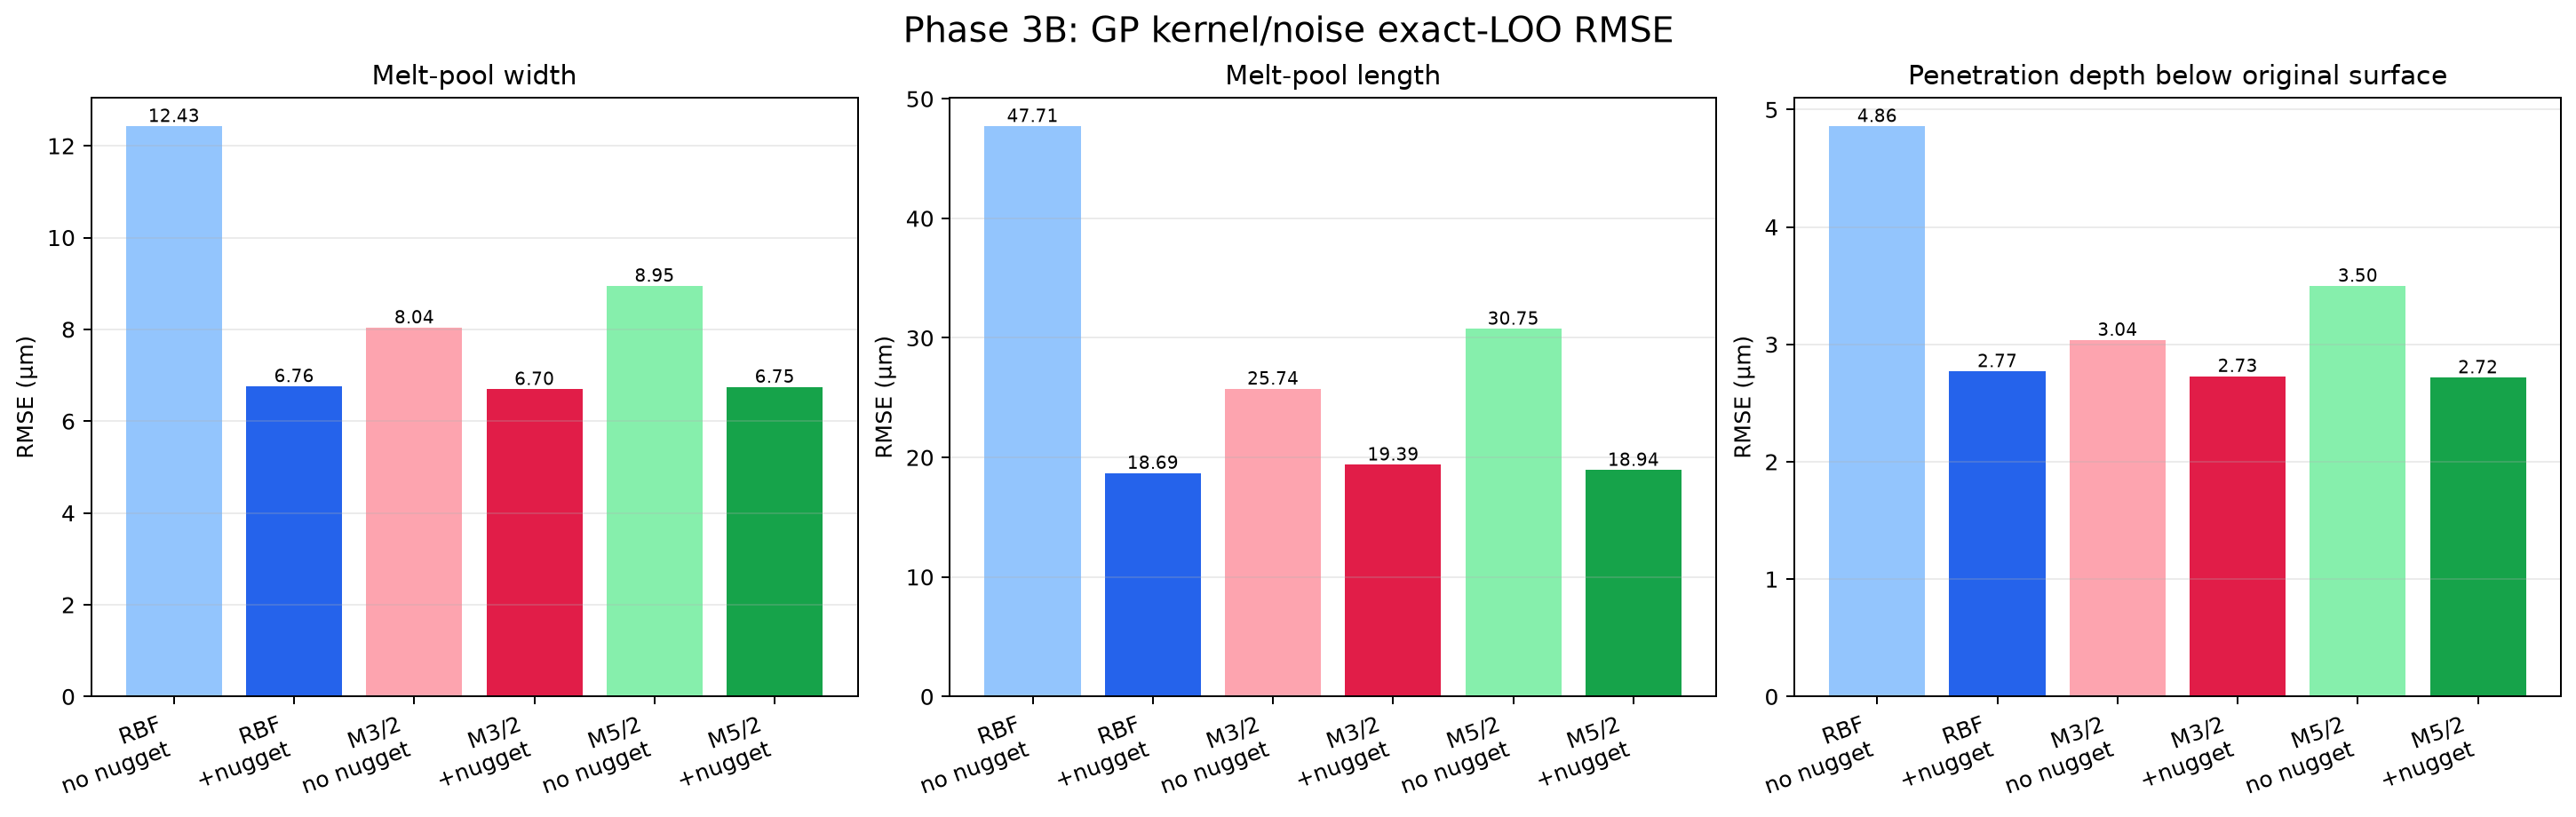

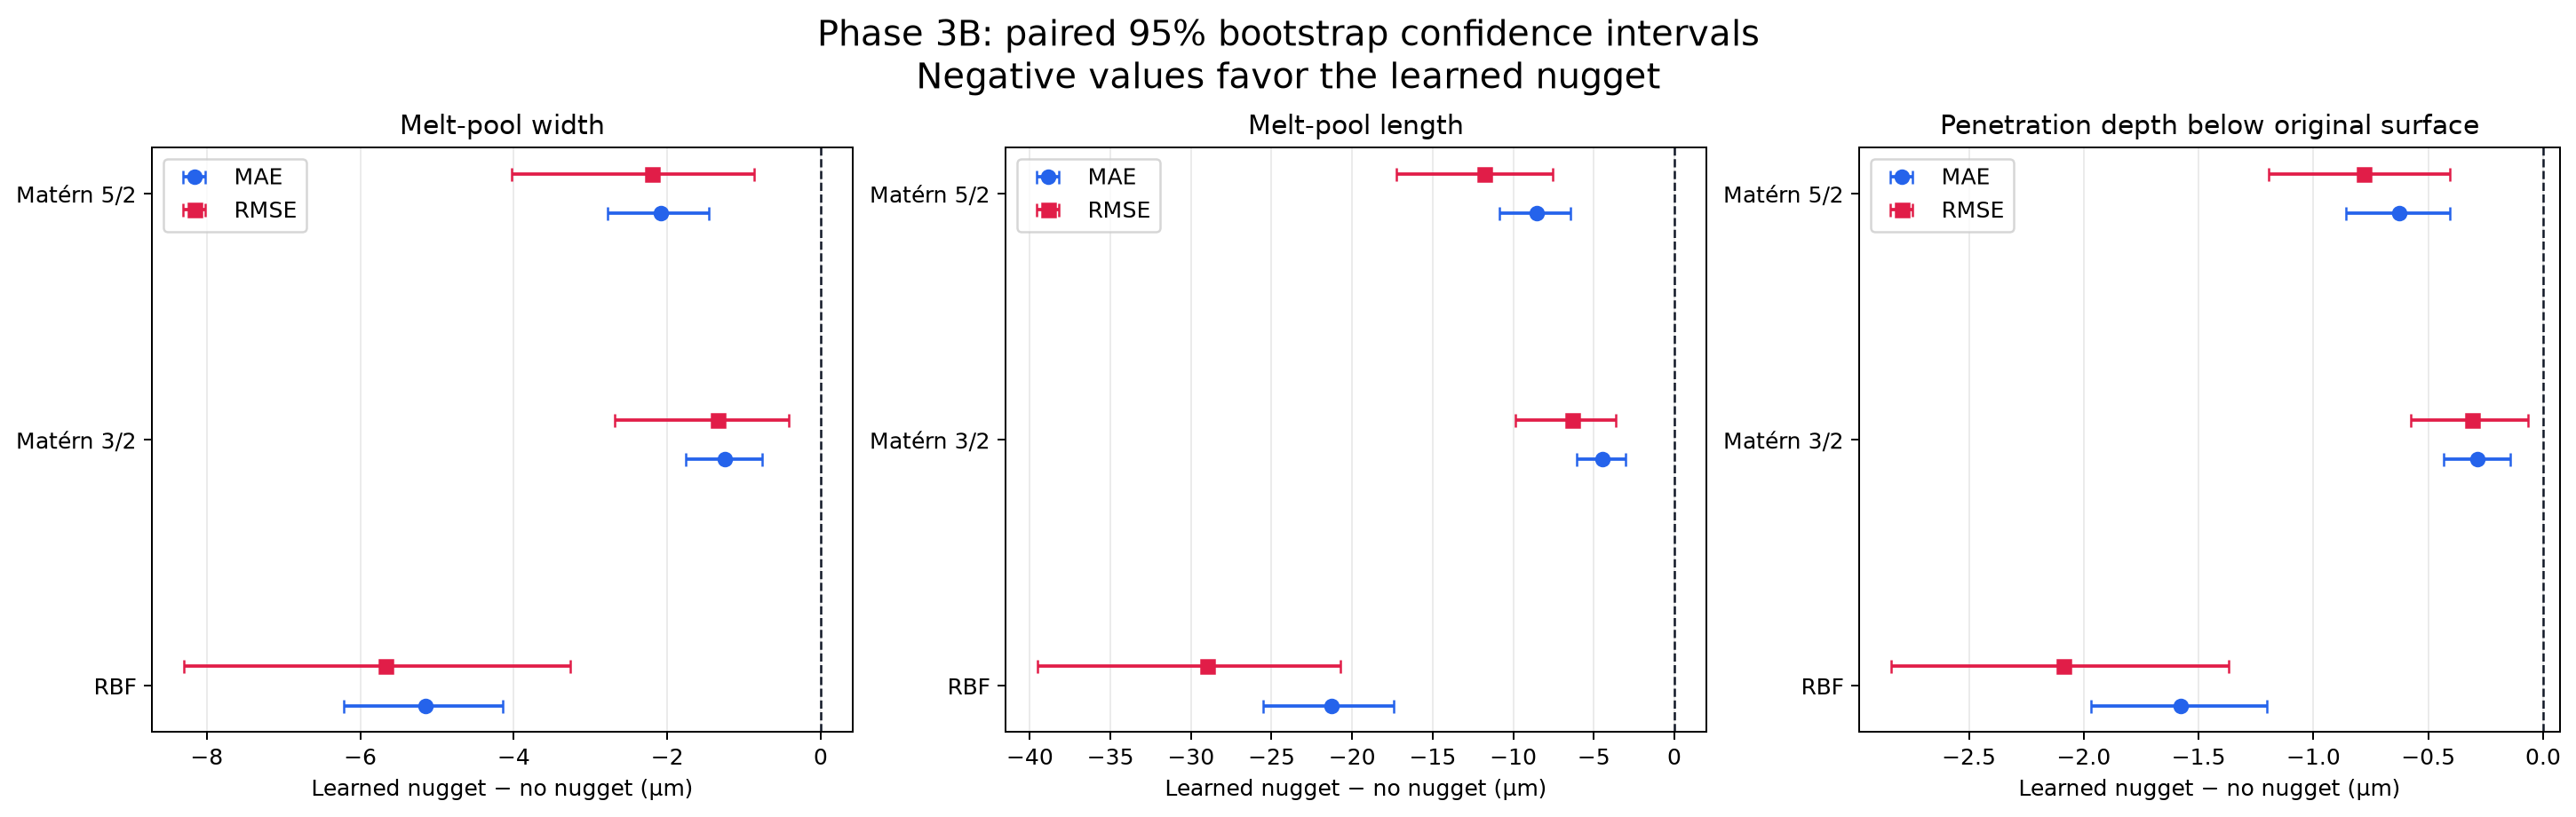

In [4]:
gp_metrics = pd.read_csv(OUT / "gp_kernel_noise_metrics.csv")
gp_pairs = pd.read_csv(OUT / "gp_kernel_paired_bootstrap_summary.csv")
provisional = pd.read_csv(OUT / "provisional_kernel_decision.csv")
display(gp_metrics[["target", "gp_configuration", "mae_um", "rmse_um",
                    "mean_nlpd", "latent_95_coverage",
                    "total_95_coverage", "optimizer_warning_folds",
                    "any_bound_hit_folds"]])
display(provisional[["target", "selected_provisional_gp_configuration",
                     "another_kernel_replaces_current", "rationale"]])
display(Image(filename=str(FIG / "03_gp_kernel_noise_rmse_comparison.png")))
display(Image(filename=str(FIG / "04_nugget_vs_no_nugget_paired_confidence_intervals.png")))

### What the Phase 3B result means

- **Width:** provisional GP `matern32_learned_nugget`; another kernel replaces the current model = `False`.
  - RBF: nugget − no-nugget RMSE -5.667 µm (95% CI -8.299 to -3.260); learned nugget robustly improves MAE and RMSE.
  - Matérn 3/2: nugget − no-nugget RMSE -1.341 µm (95% CI -2.688 to -0.420); learned nugget robustly improves MAE and RMSE.
  - Matérn 5/2: nugget − no-nugget RMSE -2.201 µm (95% CI -4.031 to -0.864); learned nugget robustly improves MAE and RMSE.
  - Current Matérn 3/2 median learned nugget standard deviation: 6.185 µm.
- **Length:** provisional GP `matern52_learned_nugget`; another kernel replaces the current model = `True`.
  - RBF: nugget − no-nugget RMSE -29.015 µm (95% CI -39.531 to -20.717); learned nugget robustly improves MAE and RMSE.
  - Matérn 3/2: nugget − no-nugget RMSE -6.350 µm (95% CI -9.847 to -3.640); learned nugget robustly improves MAE and RMSE.
  - Matérn 5/2: nugget − no-nugget RMSE -11.812 µm (95% CI -17.268 to -7.571); learned nugget robustly improves MAE and RMSE.
  - Current Matérn 3/2 median learned nugget standard deviation: 16.171 µm.
- **Depth:** provisional GP `matern32_learned_nugget`; another kernel replaces the current model = `False`.
  - RBF: nugget − no-nugget RMSE -2.088 µm (95% CI -2.839 to -1.370); learned nugget robustly improves MAE and RMSE.
  - Matérn 3/2: nugget − no-nugget RMSE -0.308 µm (95% CI -0.576 to -0.066); learned nugget robustly improves MAE and RMSE.
  - Matérn 5/2: nugget − no-nugget RMSE -0.781 µm (95% CI -1.196 to -0.407); learned nugget robustly improves MAE and RMSE.
  - Current Matérn 3/2 median learned nugget standard deviation: 1.777 µm.

**Why it matters.** The within-family comparisons distinguish a genuinely useful nugget from one that only patched Matérn 3/2 mismatch. The candidate-versus-current comparisons then ask whether a different smoothness family deserves replacement.

**What cannot be concluded.** These are isotropic kernels under the same four inputs. They do not identify causal feature effects, and a learned nugget is not proof of stochastic simulator noise.

,target,gp_configuration,nugget_std_um_median,nugget_fraction_training_target_std_median,nugget_fraction_dataset_target_median_median,nugget_bound_hit_folds,warning_folds
0,depth,matern32_learned_nugget,1.776751,0.114805,0.032468,0,1
1,depth,matern52_learned_nugget,2.036329,0.131538,0.037212,0,0
2,depth,rbf_learned_nugget,2.295977,0.148272,0.041957,0,0
3,length,matern32_learned_nugget,16.170996,0.178629,0.047370,0,1
4,length,matern52_learned_nugget,16.596160,0.183314,0.048616,0,1
5,length,rbf_learned_nugget,16.968605,0.187434,0.049707,0,2
6,width,matern32_learned_nugget,6.184851,0.165027,0.038897,0,5
7,width,matern52_learned_nugget,6.449652,0.172084,0.040563,0,3
8,width,rbf_learned_nugget,6.531530,0.174278,0.041077,0,0


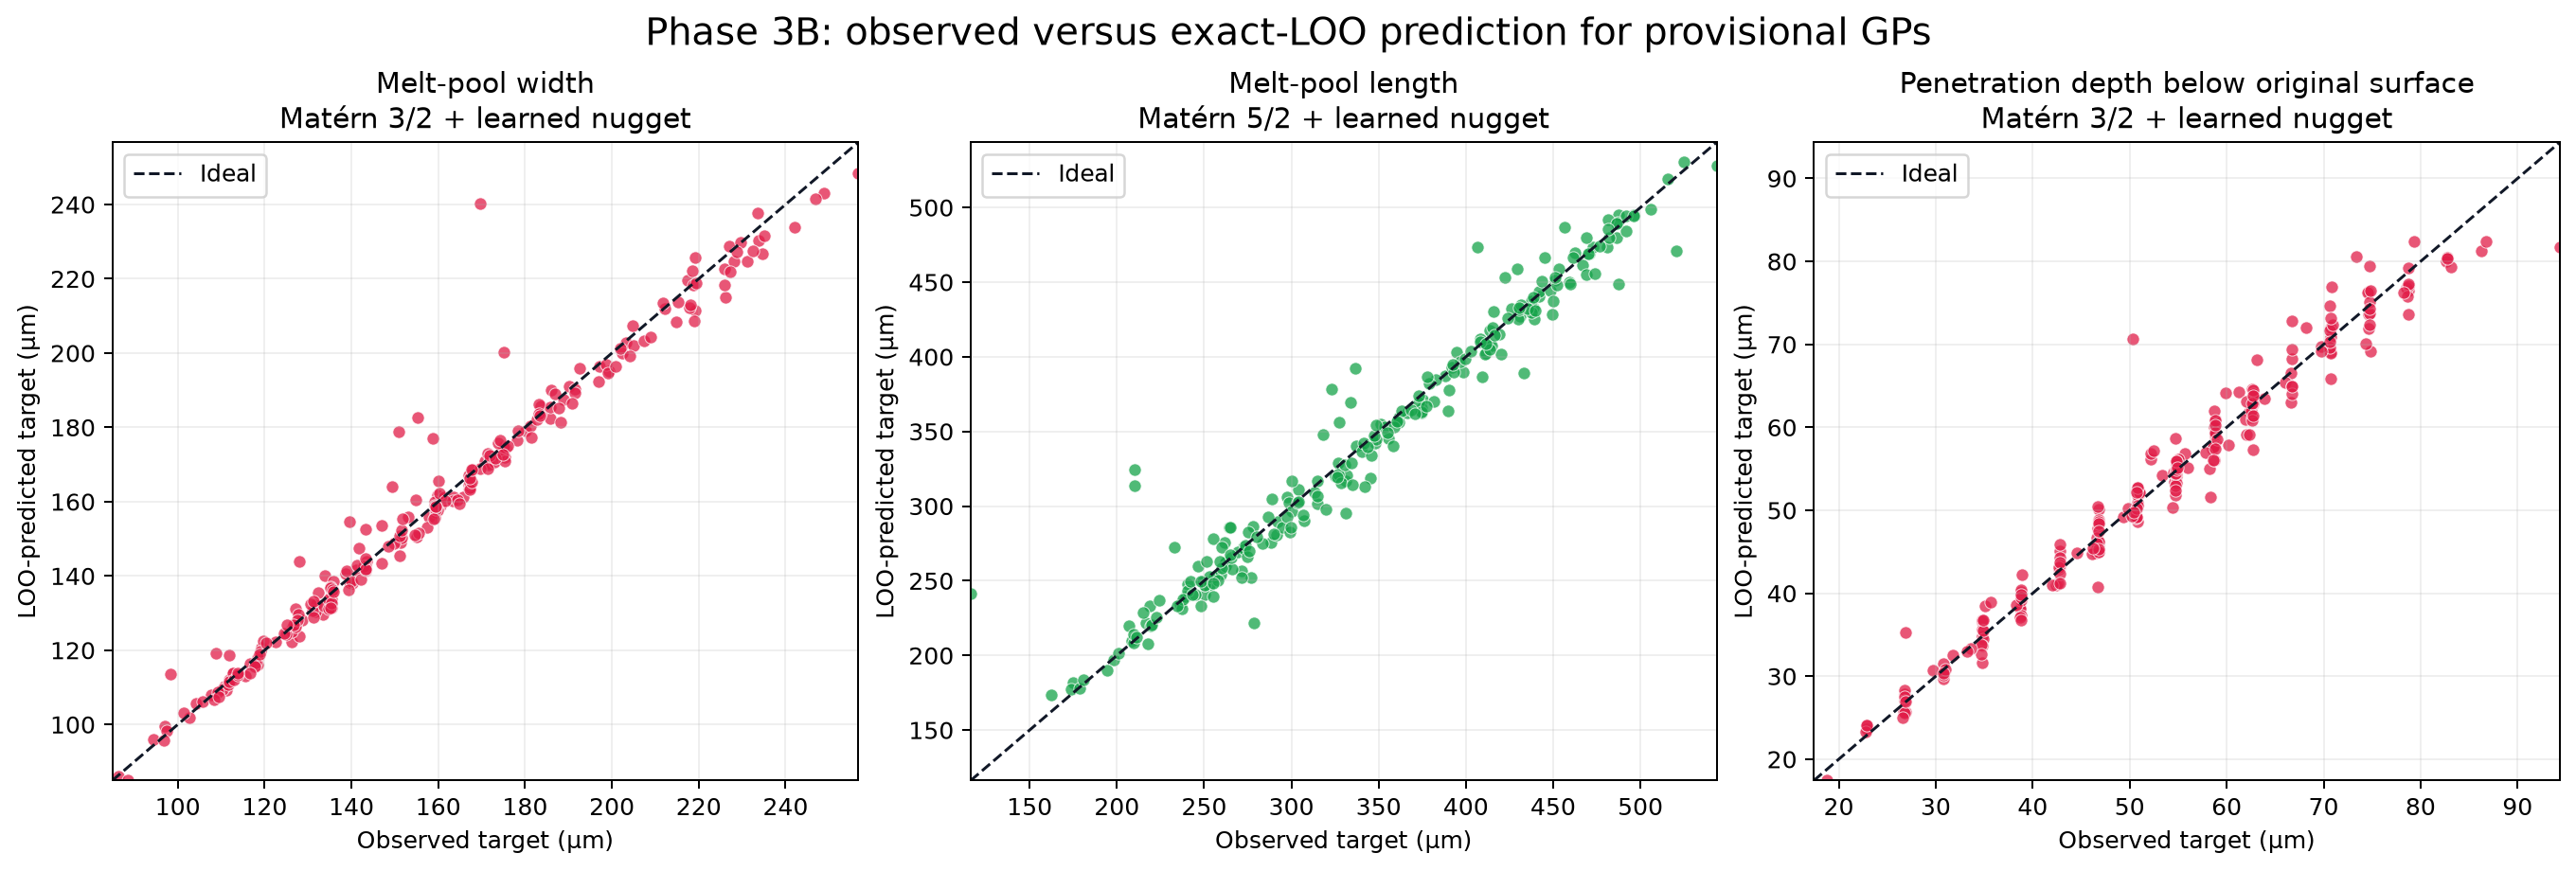

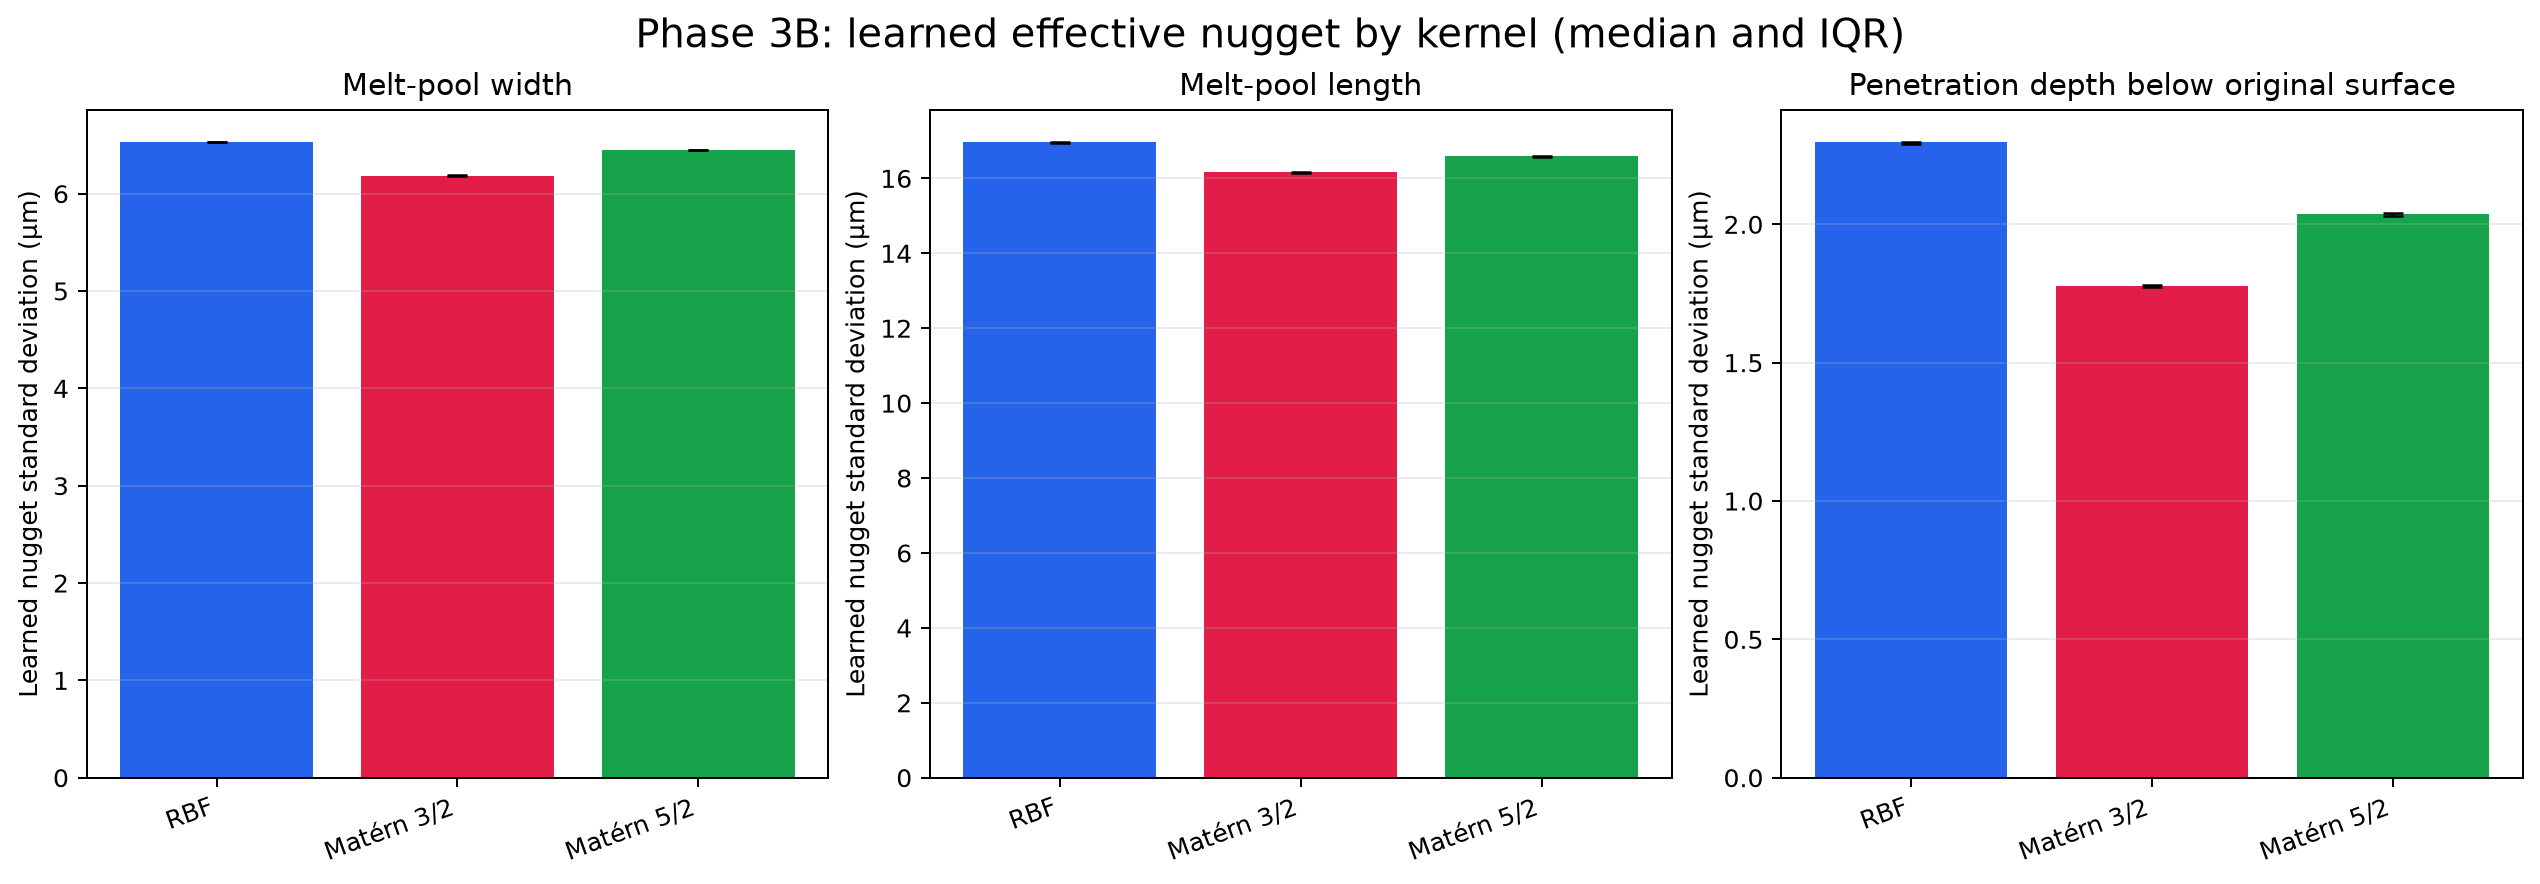

Failed GP folds: 0
Warning folds: 17
Any bound-hit folds: 0


In [5]:
nugget_summary = pd.read_csv(OUT / "learned_nugget_by_kernel_summary.csv")
diagnostics = pd.read_csv(OUT / "gp_kernel_noise_hyperparameter_diagnostics.csv")
display(nugget_summary[["target", "gp_configuration",
                        "nugget_std_um_median",
                        "nugget_fraction_training_target_std_median",
                        "nugget_fraction_dataset_target_median_median",
                        "nugget_bound_hit_folds", "warning_folds"]])
display(Image(filename=str(FIG / "05_provisional_models_observed_vs_loo_predicted.png")))
display(Image(filename=str(FIG / "06_learned_nugget_std_by_kernel_and_target.png")))
print("Failed GP folds:", int(diagnostics["failed_fold"].astype(bool).sum()))
print("Warning folds:", int((diagnostics["warning_count"] > 0).sum()))
print("Any bound-hit folds:", int(diagnostics["any_hyperparameter_bound_hit"].astype(bool).sum()))

**What was done.** Fold-level optimized signal variance, isotropic
lengthscale, nugget, warnings, and bound hits were summarized beside
observed-versus-predicted plots.

**Why.** A small RMSE gain is not a trustworthy replacement if it
depends on unstable optimization or systematic boundary solutions.

**What the result means.** Nugget sizes are shown in micrometres and
relative to both the fold's training-target standard deviation and the
population target median. These are scale diagnostics.

**What cannot be concluded.** The learned lengthscale is isotropic and
cannot be read as a separate effect for P, VX, LS, or ST.

## Part 3 — Phase 3C: target-definition sensitivity

**Target-definition sensitivity** is the change in target values,
stability, model performance, or learned nugget caused by a reasonable
change in the simulation-level summary rule.

- **Pearson correlation** measures linear association. For example,
  points exactly on a rising straight line have Pearson correlation 1.
- **Spearman correlation** measures rank association. If every
  simulation keeps the same ordering but the scale bends
  nonlinearly, Spearman can remain 1 while Pearson falls.

T0–T4 use valid non-sentinel melt rows inside a controlled active
window. T5 is the mean of the final 50 valid rows where available and
is retained as a reference because it can include shutdown or
post-domain-exit behavior. The Phase 3B provisional GP is fixed per
response across all six definitions.

,target,target_definition,availability_count,target_median_um,window_count_median,within_window_cv_median,fraction_unstable_windows,simulations_with_rows_after_full_domain_exit
0,depth,T0,230,54.722320,14083.0,0.017250,0.000000,0
1,depth,T1,230,54.475358,7041.5,0.015410,0.000000,0
2,depth,T2,230,54.752015,21125.0,0.019968,0.004348,0
3,depth,T3,230,54.767130,13743.5,0.003635,0.004348,0
4,depth,T4,230,54.591215,14706.0,0.034364,0.000000,0
5,depth,T5,230,31.060878,50.0,0.000069,0.000000,108
6,length,T0,241,341.375900,13751.0,0.013132,0.004149,0
7,length,T1,241,341.752250,6876.0,0.009088,0.000000,0
8,length,T2,241,340.436700,20627.0,0.018905,0.004149,0
9,length,T3,241,342.504650,13744.0,0.011633,0.004149,0


,target,target_definition,pearson_correlation_with_t0,spearman_correlation_with_t0,median_absolute_difference_from_t0_um,q95_absolute_difference_from_t0_um,fraction_absolute_difference_exceeds_1_um,fraction_absolute_difference_exceeds_current_learned_nugget_std,fraction_absolute_difference_exceeds_5pct_t0
0,depth,T0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,depth,T1,0.994491,0.995572,0.100433,3.780326,0.360870,0.321739,0.195652
2,depth,T2,0.996112,0.997869,0.041498,3.701573,0.191304,0.160870,0.108696
3,depth,T3,0.996090,0.997556,0.010938,3.654519,0.156522,0.126087,0.091304
4,depth,T4,0.995787,0.995973,0.017853,3.791348,0.278261,0.239130,0.195652
5,depth,T5,0.626031,0.626590,7.995310,58.797016,0.656522,0.647826,0.626087
6,length,T0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,length,T1,0.998491,0.997816,2.828950,9.506700,0.792531,0.004149,0.008299
8,length,T2,0.999115,0.998811,2.445000,8.929700,0.854772,0.000000,0.004149
9,length,T3,0.999285,0.998759,0.247650,6.185900,0.423237,0.004149,0.004149


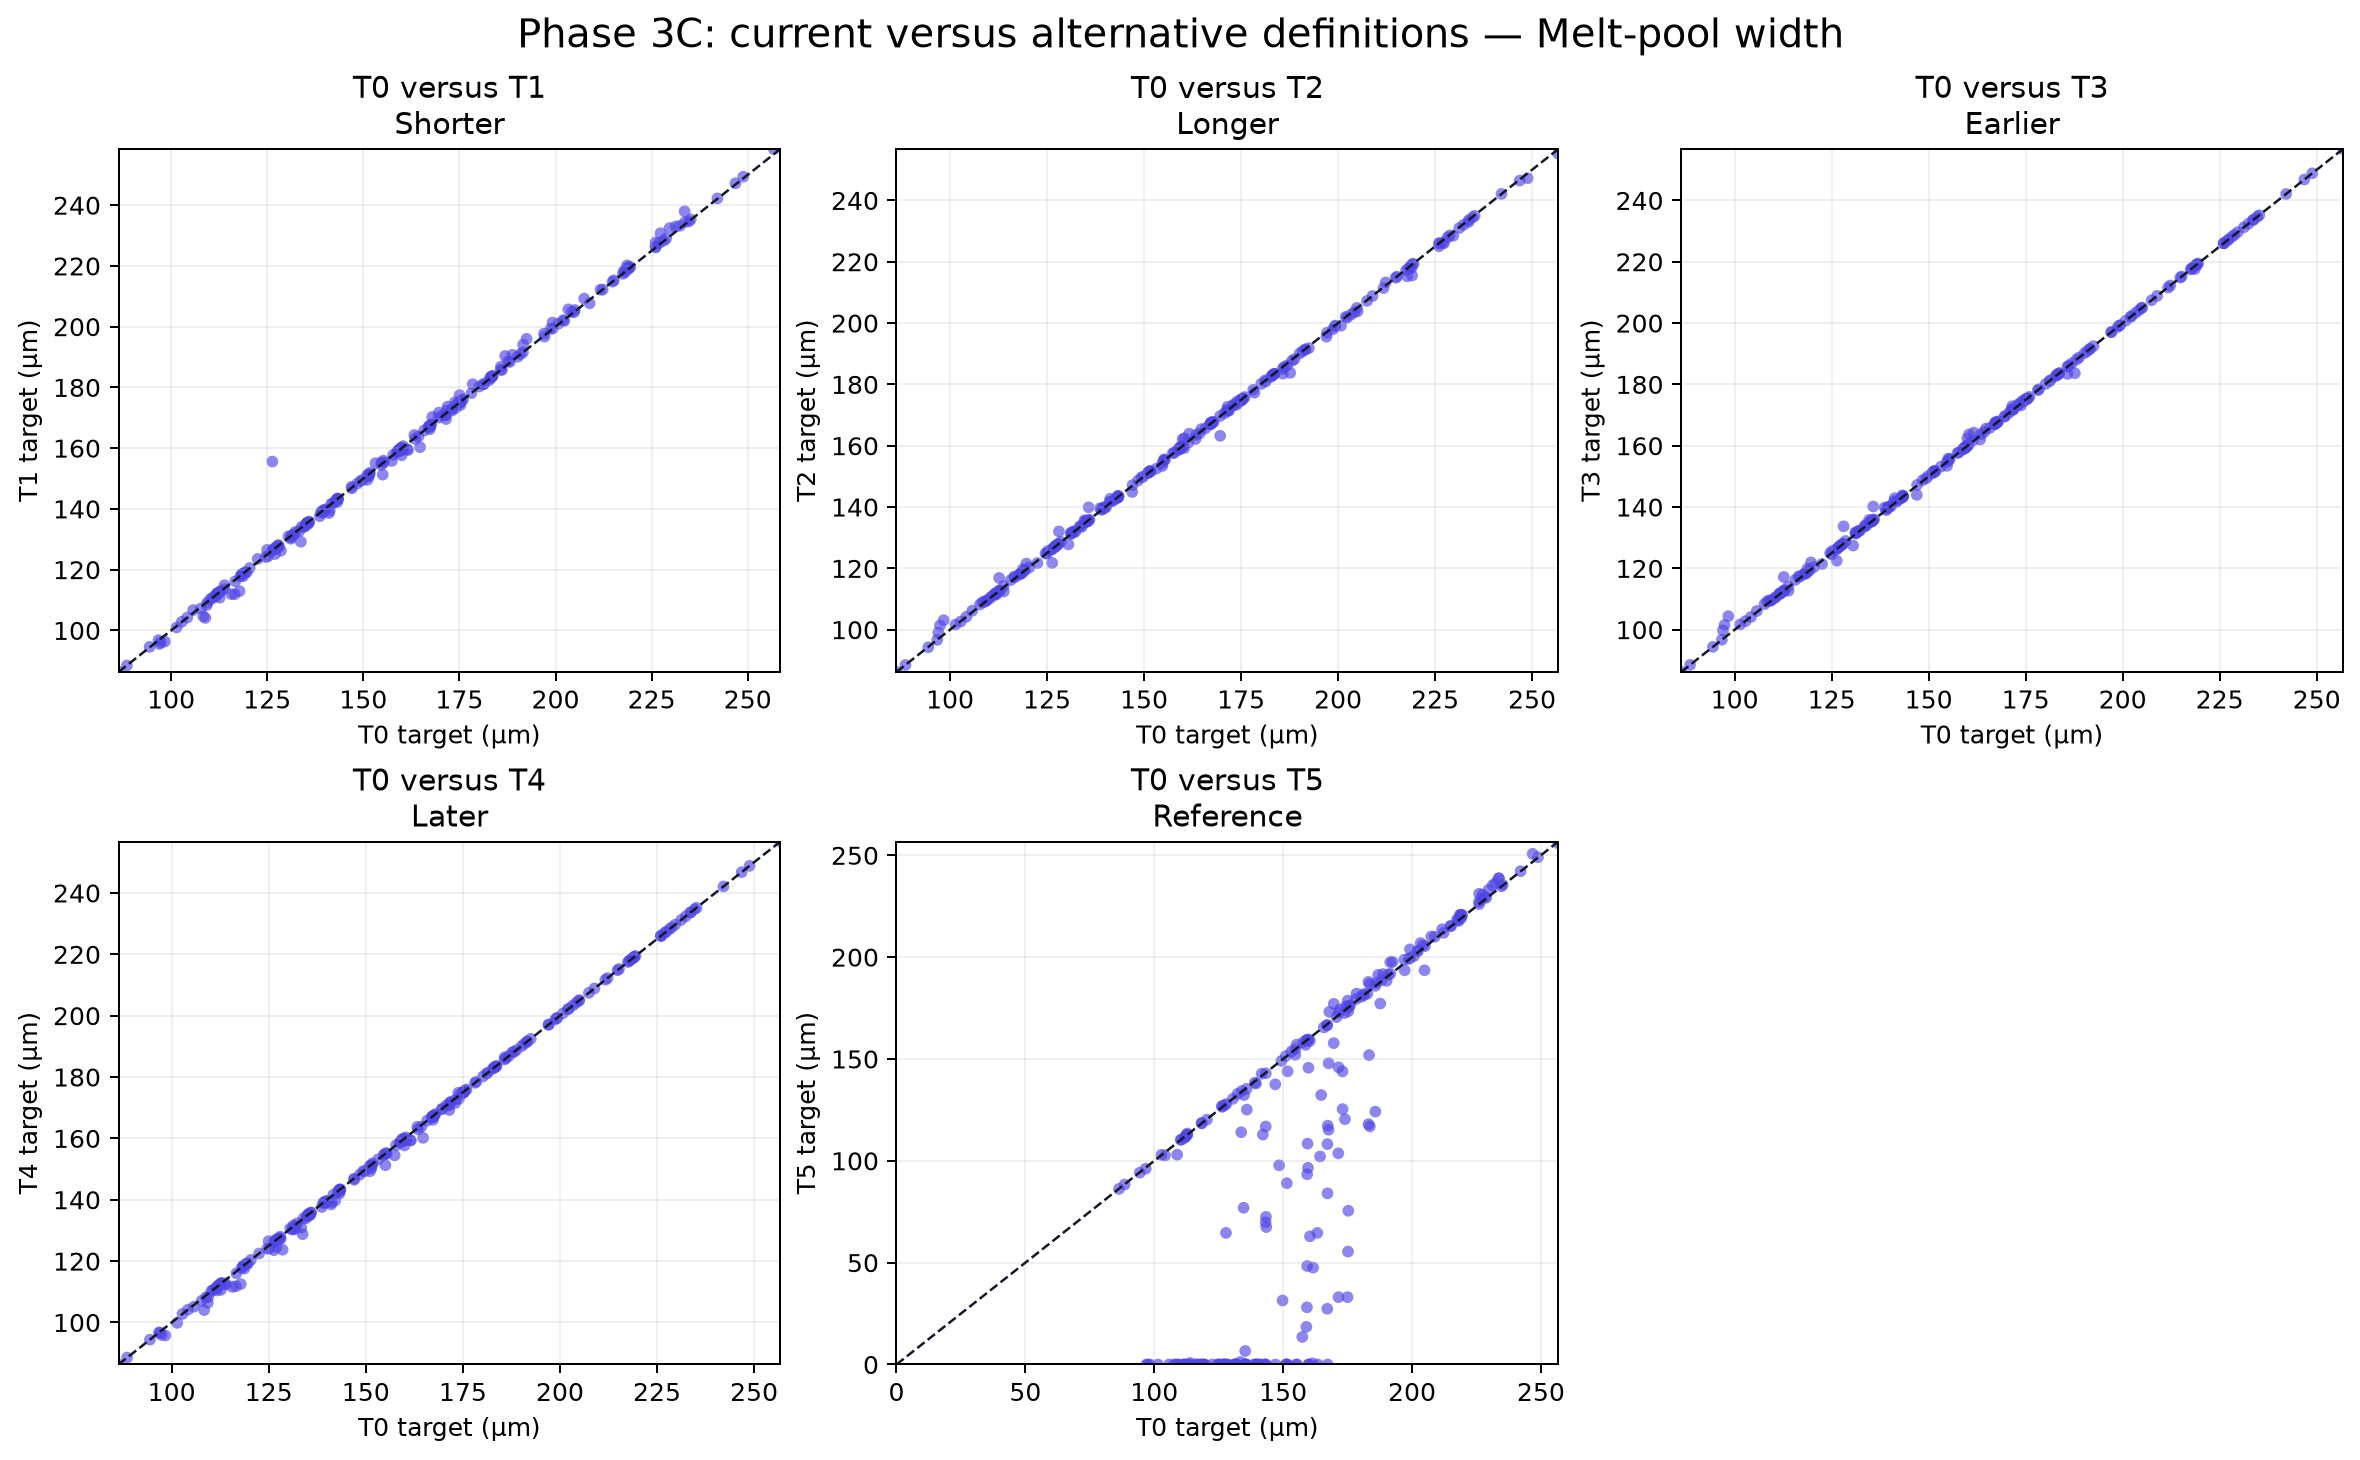

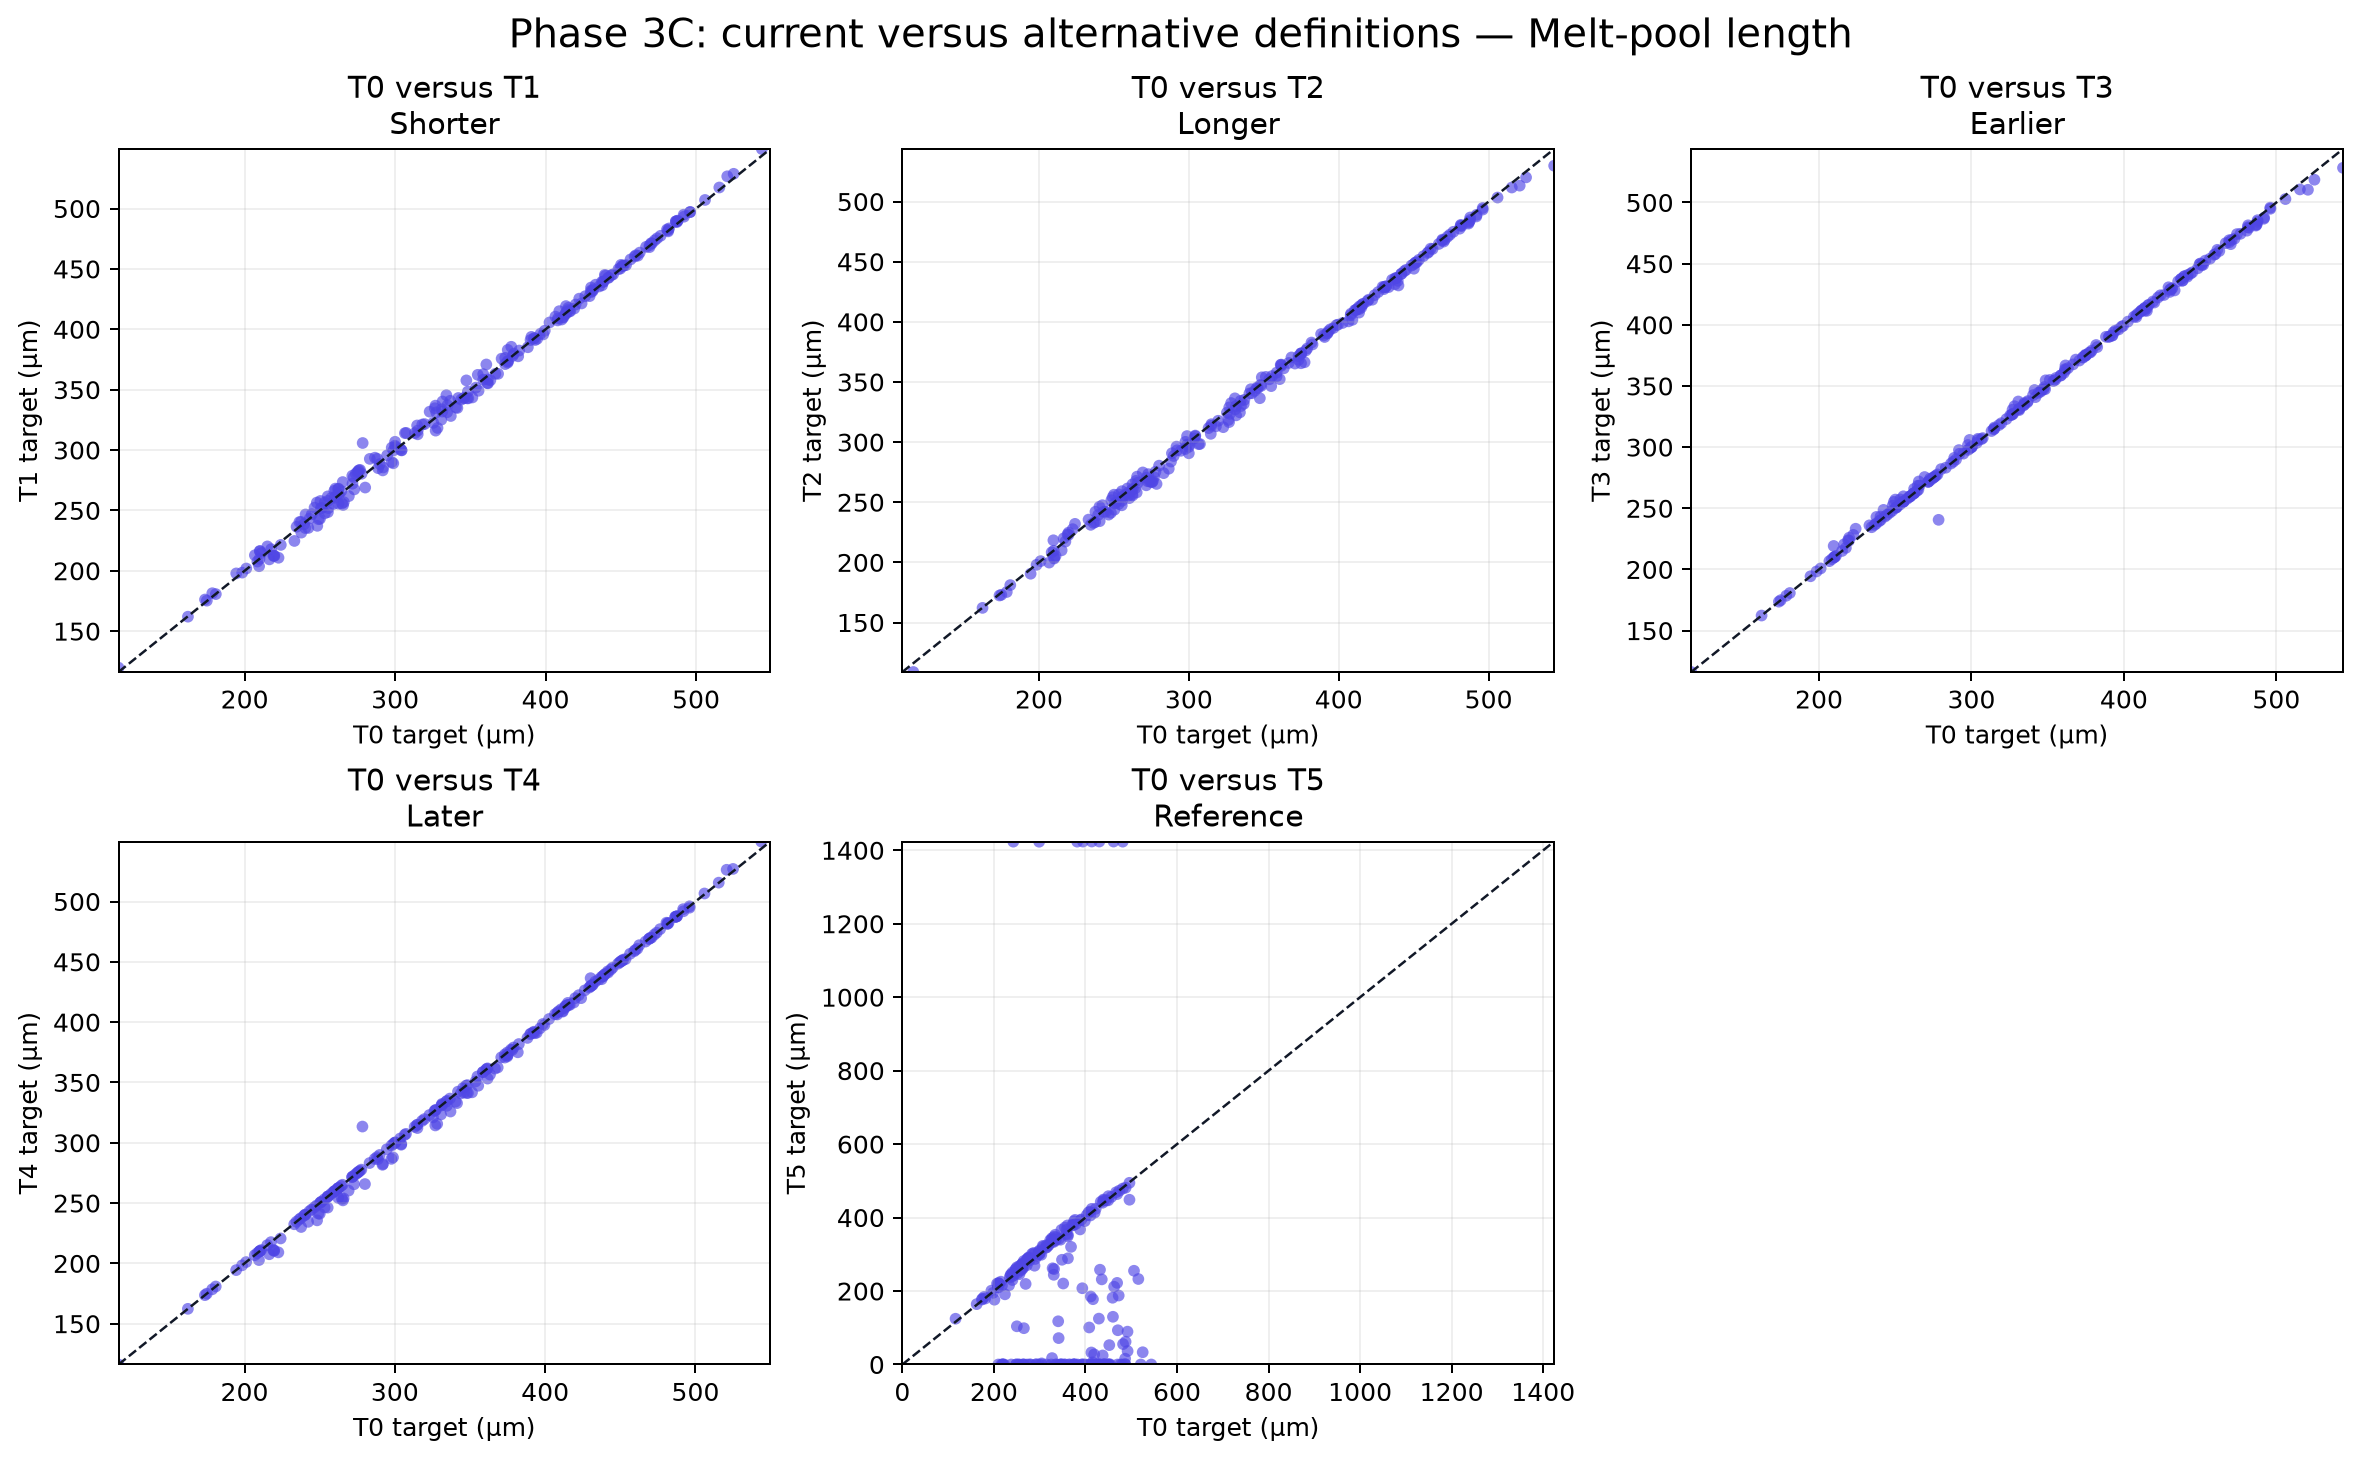

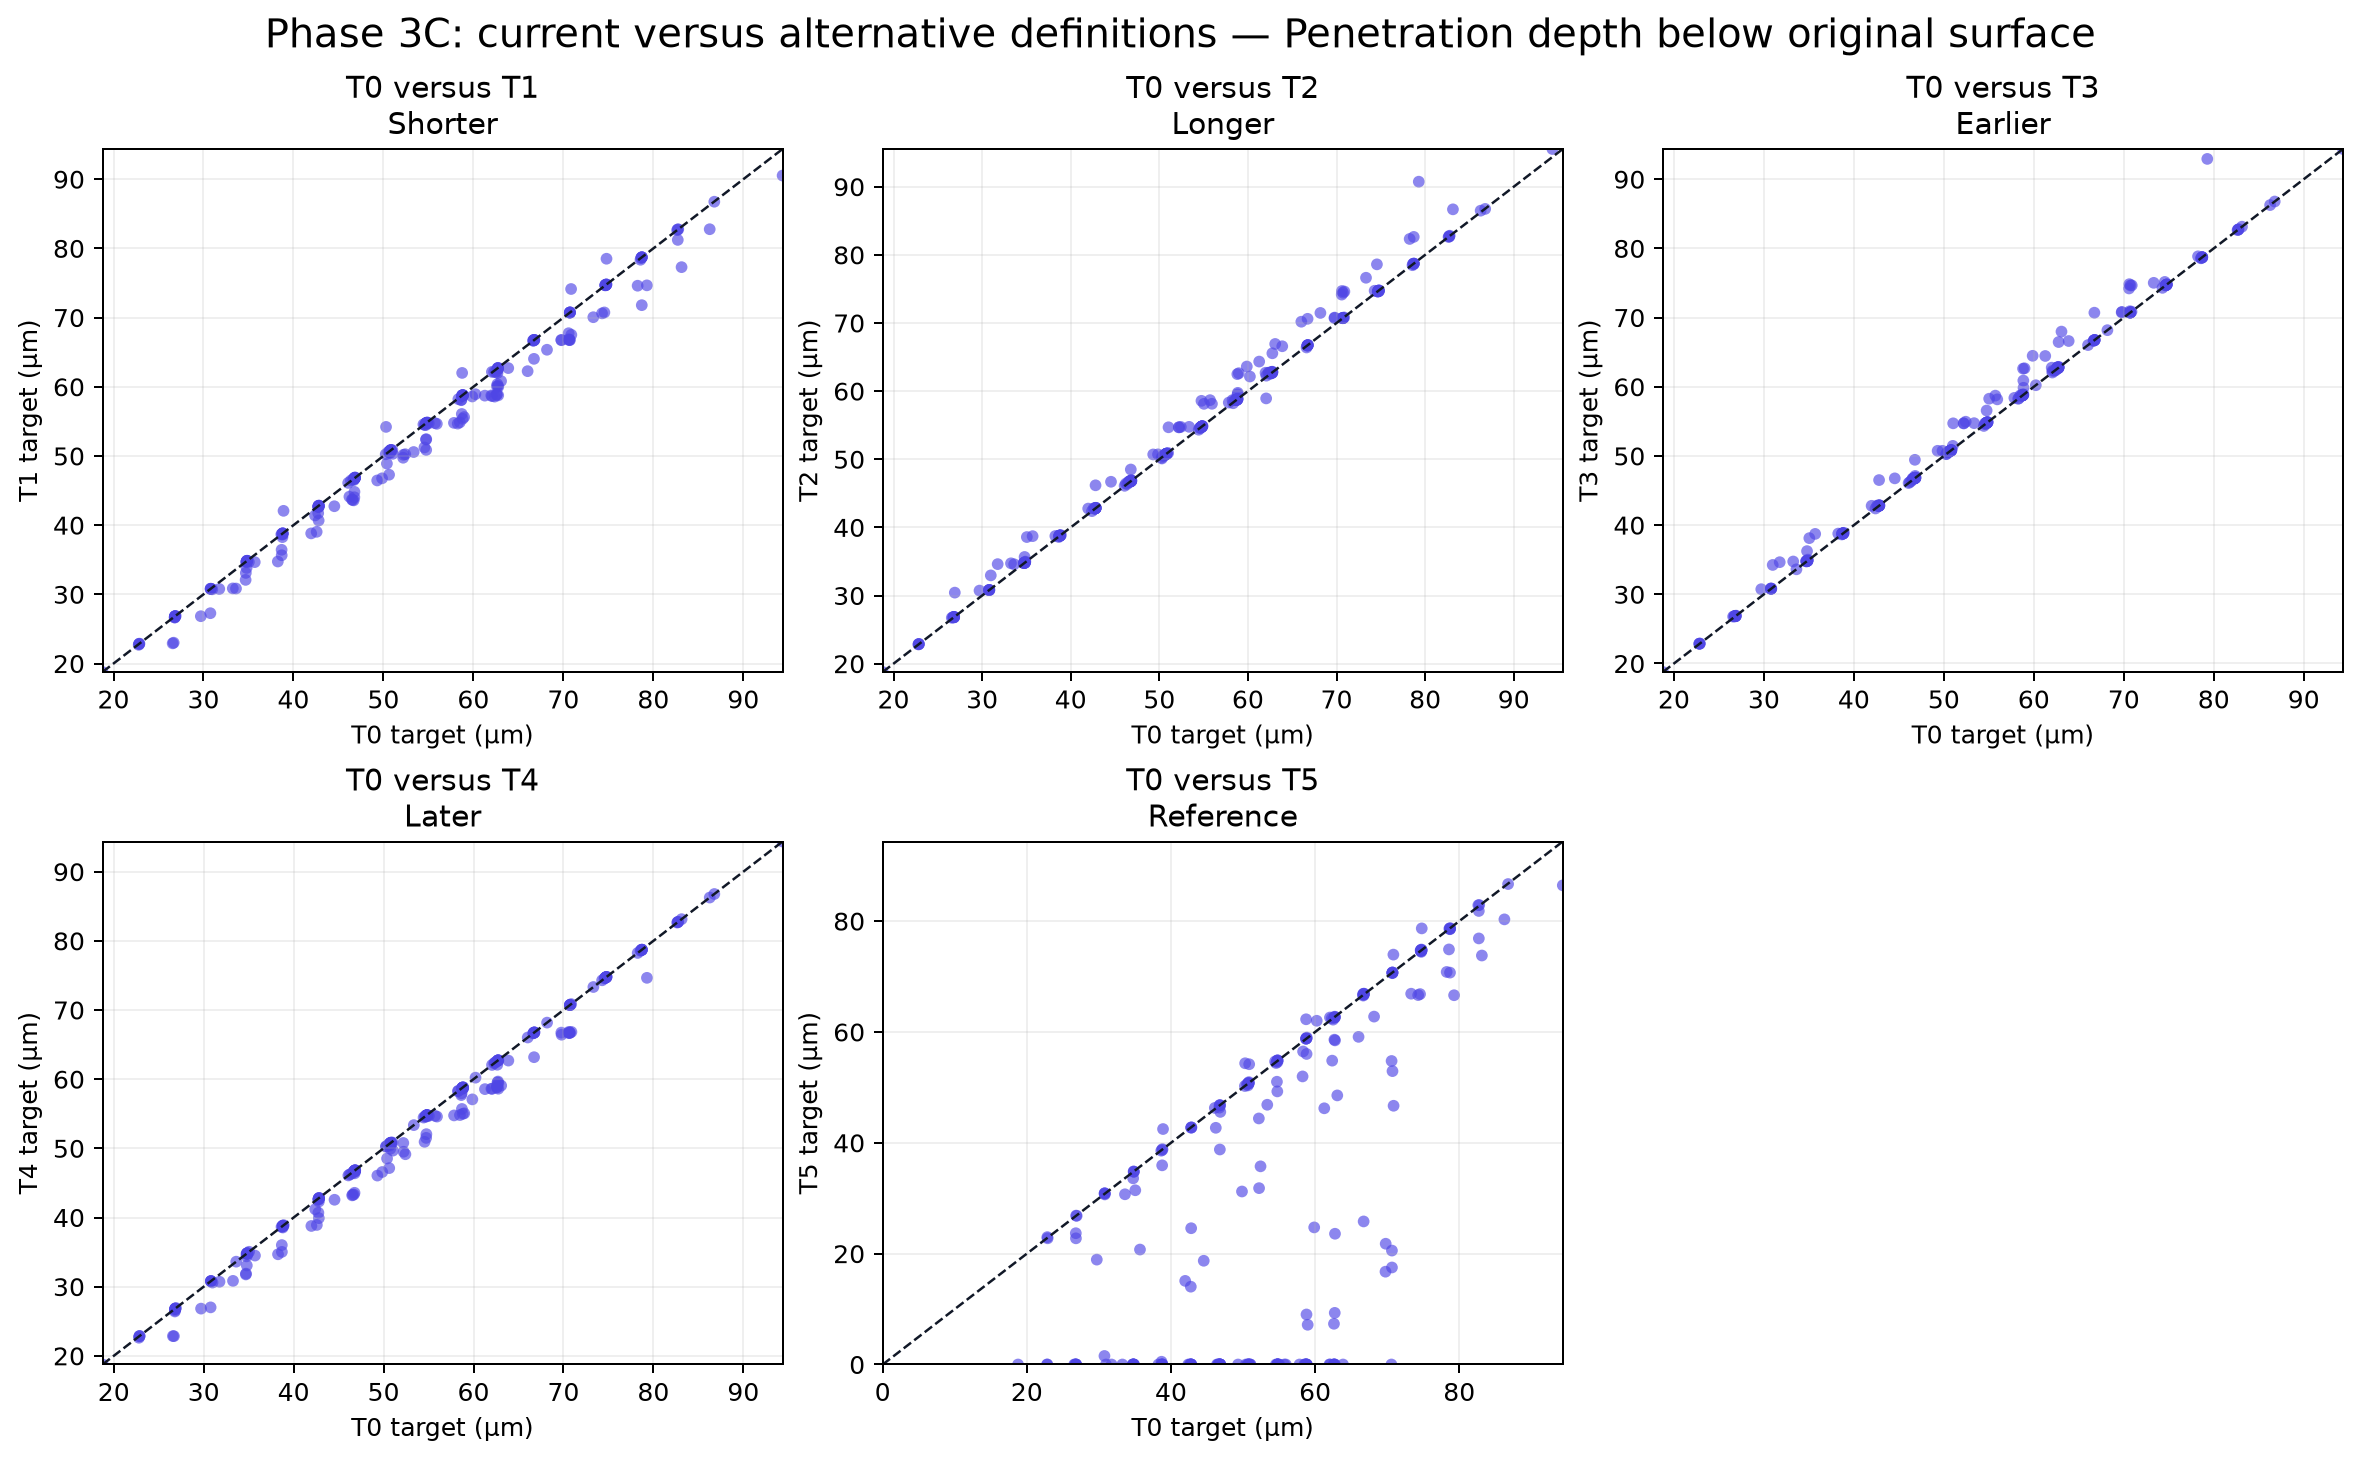

In [6]:
target_distribution = pd.read_csv(OUT / "target_definition_distribution_summary.csv")
target_difference = pd.read_csv(OUT / "target_definition_difference_summary.csv")
display(target_distribution[["target", "target_definition",
                             "availability_count", "target_median_um",
                             "window_count_median",
                             "within_window_cv_median",
                             "fraction_unstable_windows",
                             "simulations_with_rows_after_full_domain_exit"]])
display(target_difference[["target", "target_definition",
                           "pearson_correlation_with_t0",
                           "spearman_correlation_with_t0",
                           "median_absolute_difference_from_t0_um",
                           "q95_absolute_difference_from_t0_um",
                           "fraction_absolute_difference_exceeds_1_um",
                           "fraction_absolute_difference_exceeds_current_learned_nugget_std",
                           "fraction_absolute_difference_exceeds_5pct_t0"]])
for target in ["width", "length", "depth"]:
    display(Image(filename=str(FIG / f"07_target_definition_scatter_{target}.png")))

### What the Phase 3C result means

- **Width:** largest median absolute shift is T5 at 7.440 µm (q95 143.867 µm). Selected target = `T0`; substantial sensitivity = `True`.
- **Length:** largest median absolute shift is T5 at 20.494 µm (q95 485.682 µm). Selected target = `T3`; substantial sensitivity = `True`.
- **Depth:** largest median absolute shift is T5 at 7.995 µm (q95 58.797 µm). Selected target = `T0`; substantial sensitivity = `True`.

**Why it matters.** A model can predict an alternative target more easily simply because the physical quantity changed. The target decision therefore combines availability, temporal stability, domain-exit control, physical meaning, and paired predictability.

**What cannot be concluded.** The target-shift scale is not the same thing as the GP nugget. Phase 3C holds one GP fixed per response, so it does not re-run kernel selection separately for T1–T5.

,target,target_definition,gp_configuration,mae_um,rmse_um,r2,nrmse,mean_nlpd,evaluation_95_coverage,optimizer_warning_folds,any_bound_hit_folds
0,depth,T0,matern32_learned_nugget,1.802271,2.728943,0.968873,0.036104,2.440425,0.952174,1,0
1,depth,T1,matern32_learned_nugget,1.853905,2.845356,0.965296,0.039655,2.467058,0.930435,1,0
2,depth,T2,matern32_learned_nugget,1.685902,2.473318,0.975426,0.032223,2.354523,0.952174,0,0
3,depth,T3,matern32_learned_nugget,1.647586,2.515779,0.974233,0.033280,2.371585,0.956522,2,0
4,depth,T4,matern32_learned_nugget,1.973219,3.034078,0.961832,0.040124,2.534372,0.956522,0,0
5,depth,T5,matern32_learned_nugget,6.479184,11.172784,0.856028,0.128879,3.876053,0.943478,0,0
6,length,T0,matern52_learned_nugget,10.361960,18.940151,0.956167,0.044298,4.437770,0.954357,1,0
7,length,T1,matern52_learned_nugget,10.618359,19.381510,0.954641,0.045116,4.447394,0.954357,0,0
8,length,T2,matern52_learned_nugget,10.351509,19.220351,0.954394,0.045655,4.455412,0.962656,1,0
9,length,T3,matern52_learned_nugget,9.916961,18.336637,0.957688,0.044487,4.419133,0.970954,0,0


,target,target_definition,gp_configuration,nugget_std_um_median,warning_folds,any_bound_hit_folds
0,depth,T0,matern32_learned_nugget,1.776751,1,0
1,depth,T1,matern32_learned_nugget,1.868503,1,0
2,depth,T2,matern32_learned_nugget,1.505132,0,0
3,depth,T3,matern32_learned_nugget,1.546225,2,0
4,depth,T4,matern32_learned_nugget,1.915808,0,0
5,depth,T5,matern32_learned_nugget,9.013036,0,0
6,length,T0,matern52_learned_nugget,16.596160,1,0
7,length,T1,matern52_learned_nugget,16.464053,0,0
8,length,T2,matern52_learned_nugget,17.075538,1,0
9,length,T3,matern52_learned_nugget,16.354720,0,0


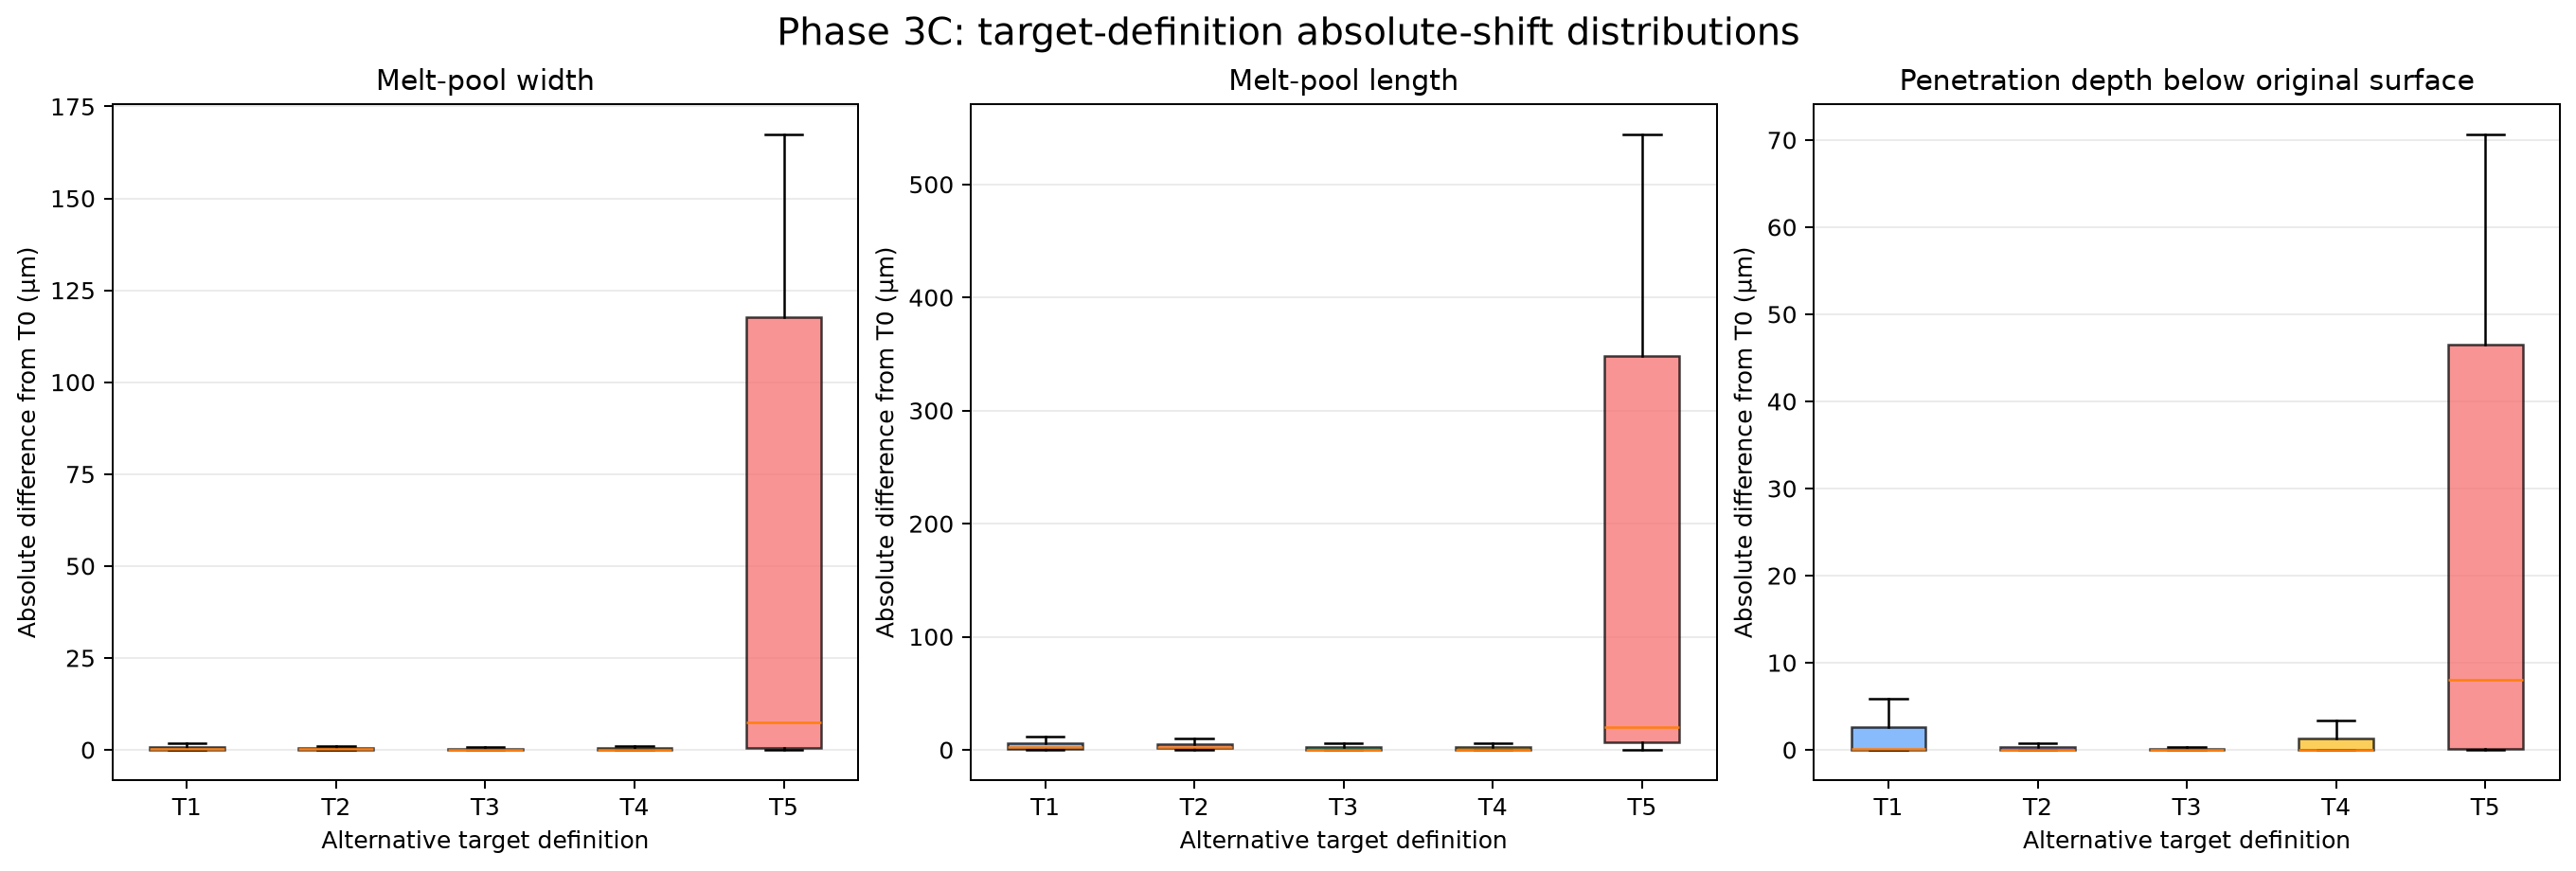

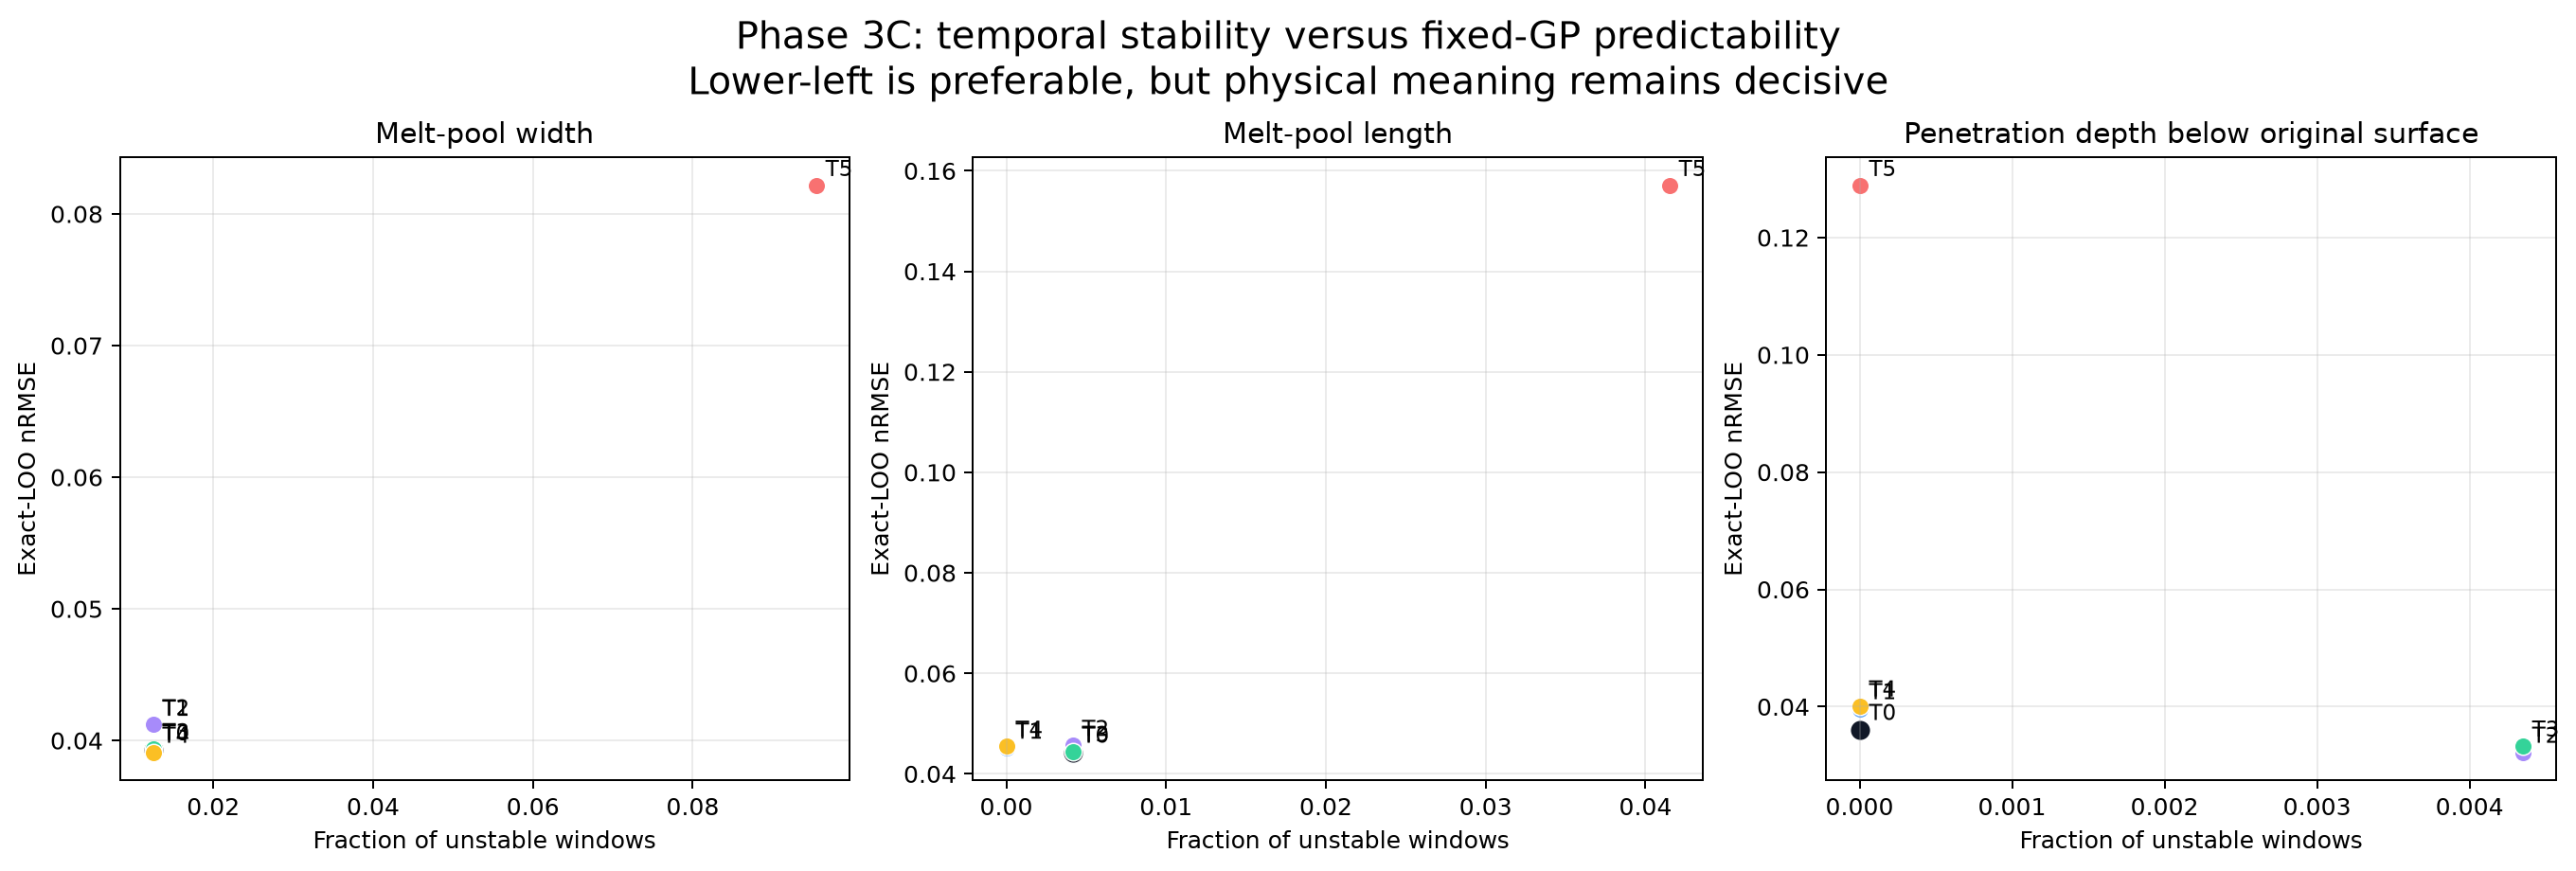

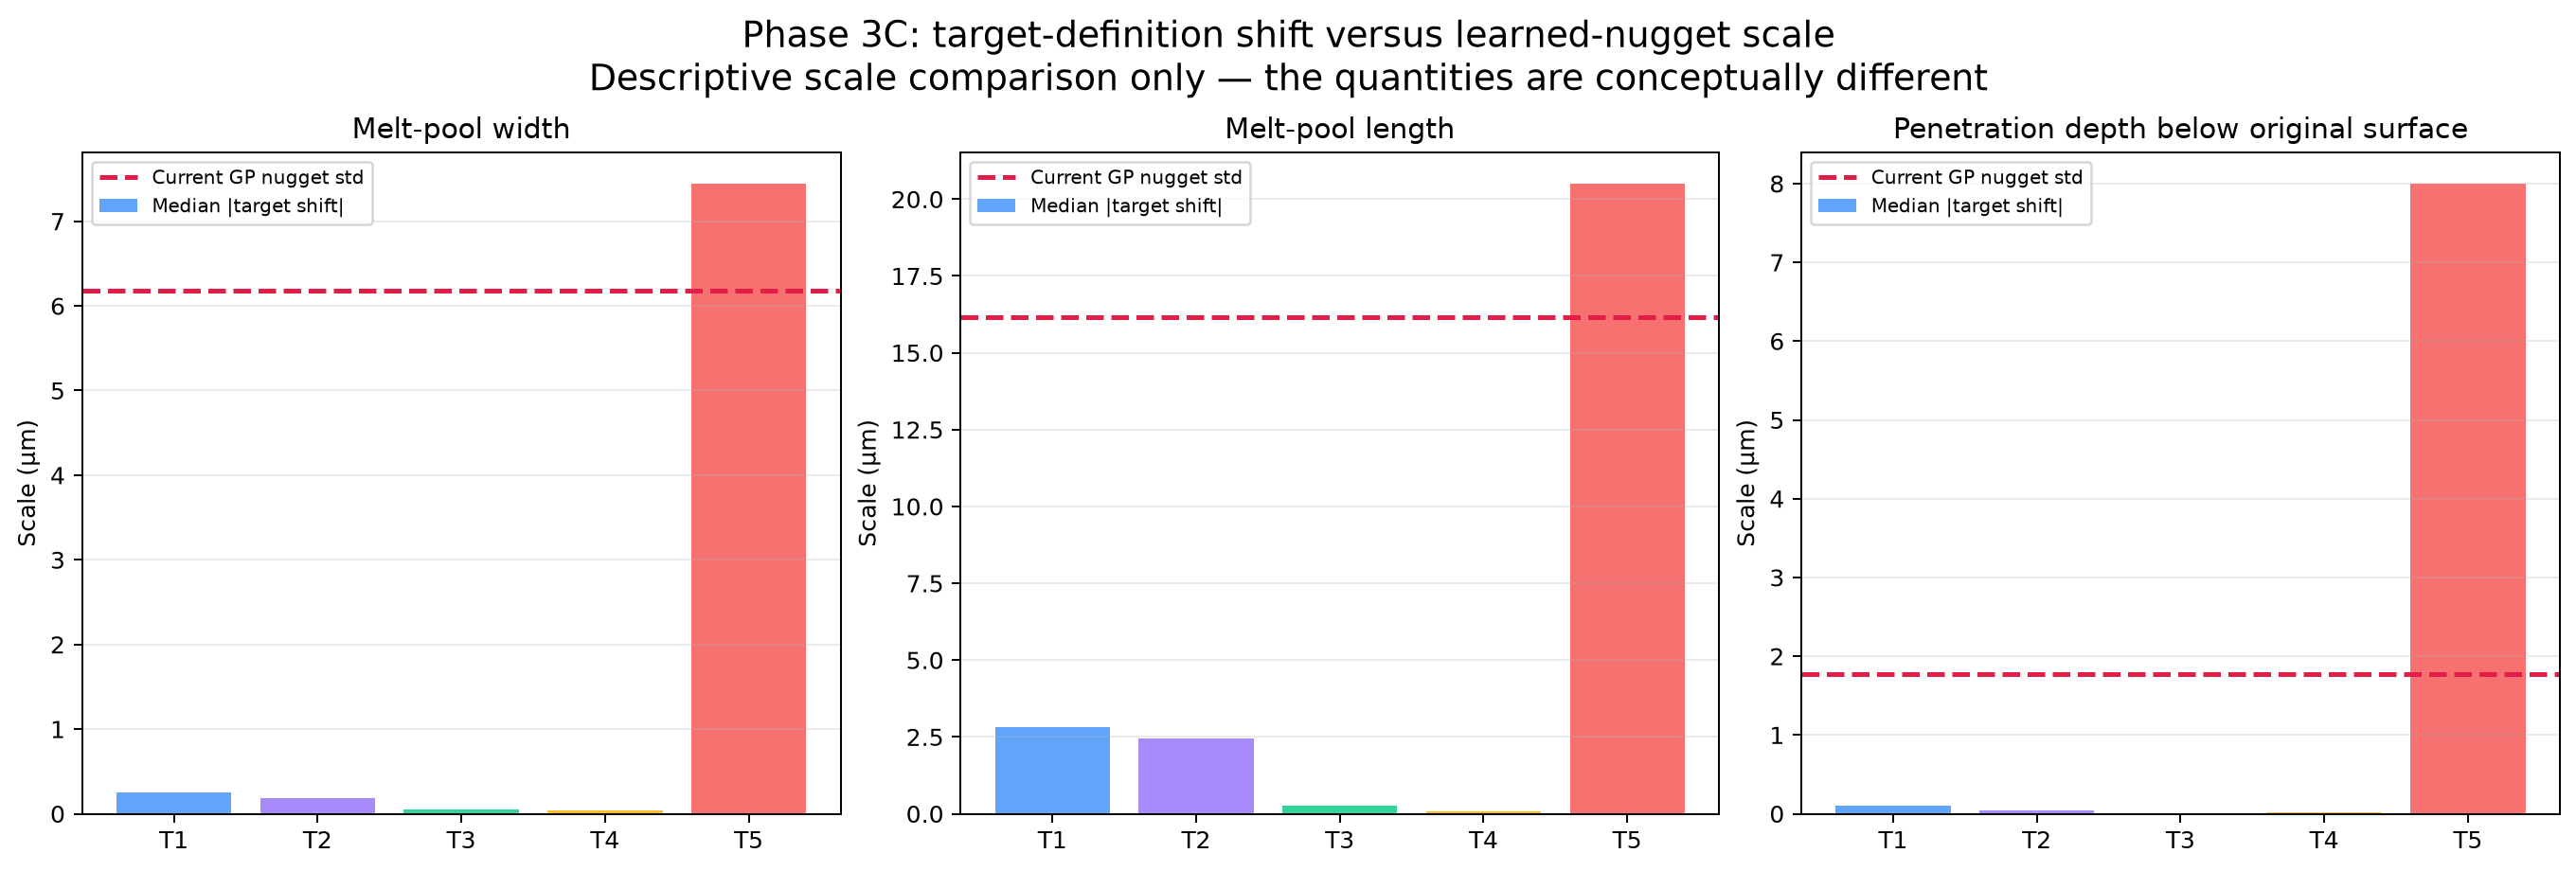

In [7]:
target_metrics = pd.read_csv(OUT / "target_definition_model_metrics.csv")
target_nuggets = pd.read_csv(OUT / "target_definition_nugget_summary.csv")
target_decisions = pd.read_csv(OUT / "target_definition_decision.csv")
display(target_metrics[["target", "target_definition",
                        "gp_configuration", "mae_um", "rmse_um",
                        "r2", "nrmse", "mean_nlpd",
                        "evaluation_95_coverage",
                        "optimizer_warning_folds",
                        "any_bound_hit_folds"]])
display(target_nuggets[["target", "target_definition",
                        "gp_configuration",
                        "nugget_std_um_median",
                        "warning_folds", "any_bound_hit_folds"]])
display(Image(filename=str(FIG / "08_target_definition_absolute_difference_distributions.png")))
display(Image(filename=str(FIG / "09_target_stability_vs_predictability.png")))
display(Image(filename=str(FIG / "10_learned_nugget_vs_target_definition_shift.png")))

**What was done.** Exact outer LOO was repeated for T0–T5 with the
response-specific provisional GP held fixed. Predictability, NLPD,
coverage, interval width, nugget, and optimizer behavior were retained.

**Why.** Holding the GP fixed prevents a new kernel search from being
confused with the target-definition change.

**What the result means.** The stability-versus-nRMSE plot reveals
trade-offs, while the nugget-versus-shift plot compares scales only.
A lower RMSE does not by itself make an alternative target physically
preferable.

**What cannot be concluded.** Phase 3C does not prove which temporal
definition is physically true, and the two scales in the last figure
measure different concepts.

In [8]:
display(target_decisions[["target", "selected_target_definition",
                          "t0_retained",
                          "target_definition_sensitivity_substantial",
                          "fixed_gp_performance_or_nugget_materially_sensitive",
                          "rationale", "physical_quantity_change"]])

,target,selected_target_definition,t0_retained,target_definition_sensitivity_substantial,fixed_gp_performance_or_nugget_materially_sensitive,rationale,physical_quantity_change
0,width,T0,True,True,True,No alternative jointly improves physical inter...,None; retain the current late-active T0 quantity.
1,length,T3,False,True,True,"T3 uniquely satisfies the physical, stability,...",The selected target is the late-active respons...
2,depth,T0,True,True,True,No alternative jointly improves physical inter...,None; retain the current late-active T0 quantity.


**What was done.** Each response was evaluated against the predeclared
target rule: physical meaning, temporal stability, availability,
robust paired predictability, domain-exit control, and optimizer
stability.

**Why.** This prevents a mechanically easy-to-predict but contaminated
target from replacing T0.

**What the result means.** A retained T0 preserves the Phase 1 physical
quantity. If sensitivity is substantial without a superior
alternative, that uncertainty remains an explicit limitation.

**What cannot be concluded.** Retaining T0 does not claim that all
alternatives are numerically identical.

## Final Phase 3 scorecard and validation

The final point model may be simpler than the provisional GP. When that
occurs, the provisional GP remains the tested uncertainty model because
Phase 3 did not invent Ridge intervals after the fact.

,target,target_label,selected_final_model,selected_final_model_family,selected_provisional_gp,selected_provisional_gp_label,selected_gp_kernel_family,simple_models_competitive,statistically_nonrobust_gp_vs_simple_rmse_differences,practical_rmse_difference_threshold_um,selected_final_mae_um,selected_final_rmse_um,selected_final_r2,selected_final_nrmse,learned_nugget_required_by_selected_final_model,learned_nugget_robustly_helps_selected_gp_family,selected_gp_family_nugget_conclusion,provisional_gp_retained_as_uncertainty_model_when_simple_selected,rationale,uncertainty_limit_for_simple_model
0,width,Melt-pool width,polynomial_ridge_degree2,simple regression,matern32_learned_nugget,Matérn 3/2 + learned nugget,Matérn 3/2,"[""polynomial_ridge_degree2""]","[""polynomial_ridge_degree2""]",0.500000,3.387664,6.725322,0.967729,0.039454,False,True,learned nugget robustly improves MAE and RMSE,True,polynomial_ridge_degree2 is statistically or p...,Ridge supplies point predictions only in this ...
1,length,Melt-pool length,matern52_learned_nugget,Gaussian process,matern52_learned_nugget,Matérn 5/2 + learned nugget,Matérn 5/2,[],[],0.947008,10.361960,18.940151,0.956167,0.044298,True,True,learned nugget robustly improves MAE and RMSE,False,Neither Ridge baseline is statistically or pra...,NaN
2,depth,Penetration depth below original surface,matern32_learned_nugget,Gaussian process,matern32_learned_nugget,Matérn 3/2 + learned nugget,Matérn 3/2,[],[],0.500000,1.802271,2.728943,0.968873,0.036104,True,True,learned nugget robustly improves MAE and RMSE,False,Neither Ridge baseline is statistically or pra...,NaN


,target,target_label,selected_target_definition,selected_target_definition_label,t0_retained,eligible_alternatives,alternative_evaluations,decision_rule,rationale,physical_quantity_change,target_definition_sensitivity_substantial,maximum_nugget_std_relative_change_across_definitions,maximum_nrmse_relative_change_across_definitions,fixed_gp_performance_or_nugget_materially_sensitive,kernel_preference_researched_per_definition,interpretation_limit,selected_provisional_gp_configuration
0,width,Melt-pool width,T0,Current: median over final 20% before 90% +X c...,True,[],"{""T1"":{""physical_interpretation_equal_or_bette...",retain T0 unless an alternative has equal/bett...,No alternative jointly improves physical inter...,None; retain the current late-active T0 quantity.,True,1.816079,1.091357,True,False,"The GP family was intentionally held fixed, so...",matern32_learned_nugget
1,length,Melt-pool length,T3,Earlier: median over final 20% before 85% +X c...,False,"[""T3""]","{""T1"":{""physical_interpretation_equal_or_bette...",retain T0 unless an alternative has equal/bett...,"T3 uniquely satisfies the physical, stability,...",The selected target is the late-active respons...,True,8.688029,2.545747,True,False,"The GP family was intentionally held fixed, so...",matern52_learned_nugget
2,depth,Penetration depth below original surface,T0,Current: median over final 20% before 90% +X c...,True,[],"{""T1"":{""physical_interpretation_equal_or_bette...",retain T0 unless an alternative has equal/bett...,No alternative jointly improves physical inter...,None; retain the current late-active T0 quantity.,True,4.072764,2.569712,True,False,"The GP family was intentionally held fixed, so...",matern32_learned_nugget


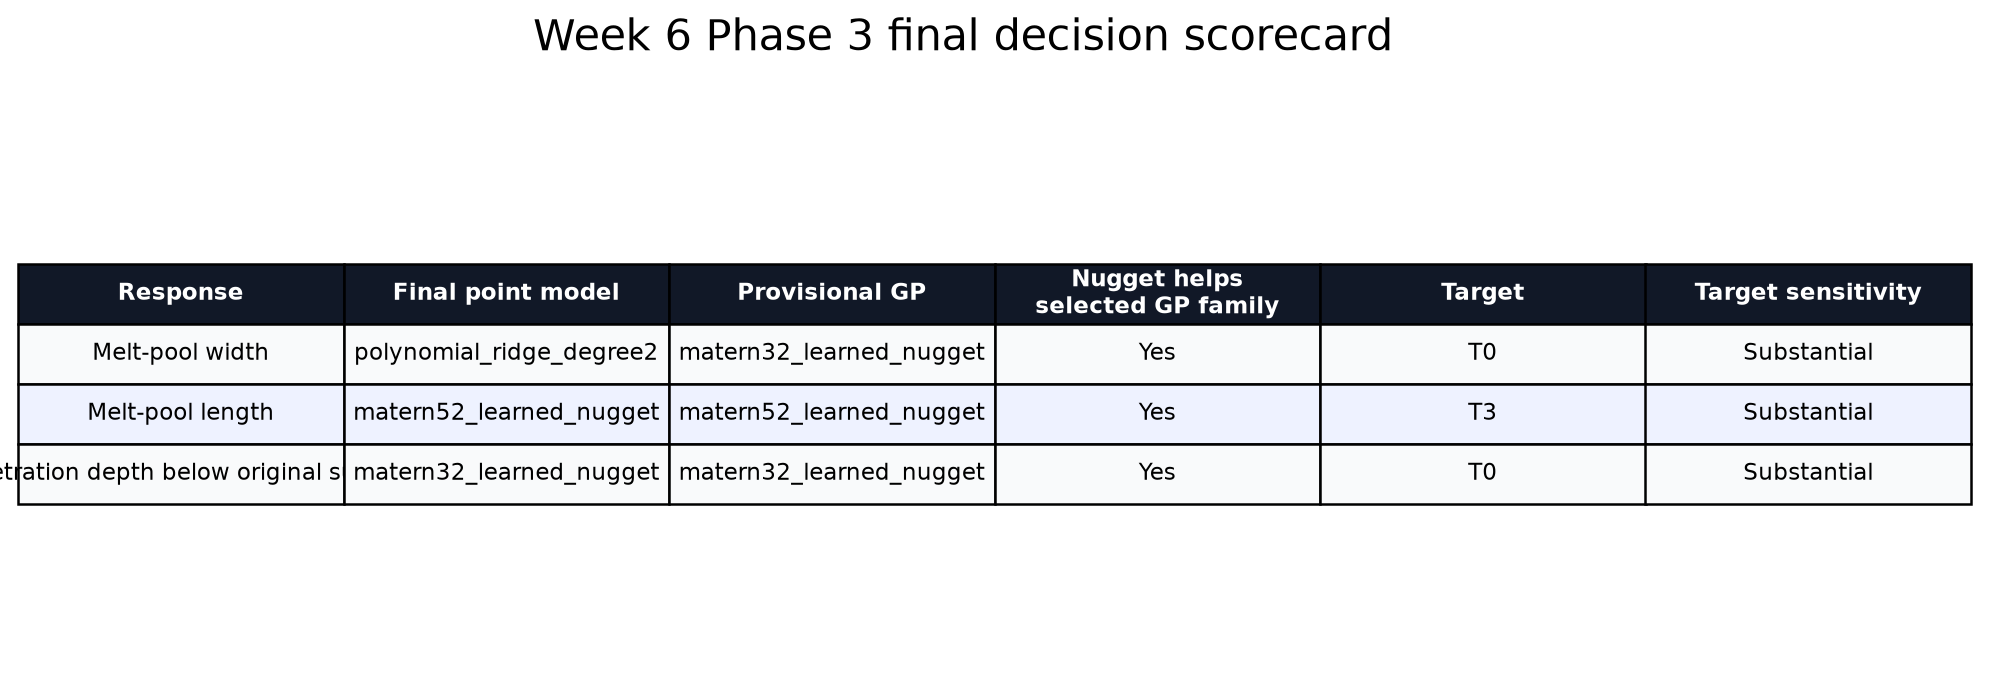

Validation: 51 / 51 PASS


,check_id,requirement,status,detail,evidence
0,V01,exact Phase 1 provenance,PASS,revision={'0e859b748fdbc8454f66e58e101e333ac04...,Phase 1 ledger; phase3_runtime_provenance.json
1,V02,unchanged Phase 1 ledger hash,PASS,sha256=10DEF11AB64D62444AC14FED506266BEB748EEB...,week6_phase1_simulation_level_responses.csv
2,V03,unchanged Phase 1 protected aggregate,PASS,aggregate=21FF34AD767C8D4D6C536D66AFD147B8C700...,Phase 1 protected files
3,V04,Phase 2 source and artifacts unchanged,PASS,checked_paths=8,"Phase 2 source, notebook, configurations, pred..."
4,V05,Phase 2.5 source and artifacts unchanged,PASS,checked_paths=6,"Phase 2.5 source, notebook, configurations, pr..."
5,V06,"features exactly P, VX, LS, ST",PASS,"features=['P', 'VX', 'LS', 'ST']",configuration and prediction rows
6,V07,width population exactly 241,PASS,rows=241,phase3_input_population_summary.csv
7,V08,length population exactly 241,PASS,rows=241,phase3_input_population_summary.csv
8,V09,depth population exactly 230,PASS,rows=230,phase3_input_population_summary.csv
9,V10,exact expected depth exclusions,PASS,"excluded=['sim_00002', 'sim_00006', 'sim_00018...",phase3_input_population_summary.csv


Requirement checklist: 43 / 43 PASS


In [9]:
final_models = pd.read_csv(OUT / "phase3_final_model_decision.csv")
final_targets = pd.read_csv(OUT / "phase3_final_target_decision.csv")
validation = pd.read_csv(OUT / "validation_results.csv")
checklist = pd.read_csv(OUT / "phase3_requirement_checklist.csv")
display(final_models)
display(final_targets)
display(Image(filename=str(FIG / "11_phase3_final_decision_scorecard.png")))
print("Validation:", int((validation["status"] == "PASS").sum()),
      "/", len(validation), "PASS")
display(validation)
print("Requirement checklist:", int((checklist["status"] == "PASS").sum()),
      "/", len(checklist), "PASS")

**What was done.** Final response-specific model and target decisions
were displayed with the complete automated validation and requirement
map.

**Why.** A scientific conclusion is only usable when its provenance,
predictions, uncertainty algebra, tuning isolation, raw-target
traceability, notebook execution, repository safety, and scope are all
checked.

**What the result means.** A complete PASS establishes internal
reproducibility for this Phase 3 protocol.

**What cannot be concluded.** Validation does not turn statistically
uncertain differences into robust ones, and Phase 4 topics remain
deferred.